<a href="https://colab.research.google.com/github/vpagonis/Python-Codes/blob/main/BayesianTL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Code 1**
Bayesian analysis of single peak TL glow curve

PYMC MODEL FOR SINGLE PEAK TL DATA - METROPOLIS SAMPLING

Fixed parameters:
  Imax1: 1.00
  Tmax1: 494.61 K

Least squares estimates (used for prior means):
  R1: 0.150 ± 0.030
  E1: 1.000 ± 0.050 eV
  sigma: 0.010 ± 0.001

Running Metropolis sampler...
Evaluating chain 1
  Chain 1 acceptance rate: 0.137
Evaluating chain 2
  Chain 2 acceptance rate: 0.115

PARAMETER SUMMARY
Parameter Mean       Std        95% HPD Lower   95% HPD Upper  
------------------------------------------------------------
R1       0.0871     0.0085     0.0708          0.1052         
E1       0.9724     0.0076     0.9585          0.9889         
sigma    0.0209     0.0021     0.0172          0.0251         

Calculating fit statistics...

R-squared: 0.9961


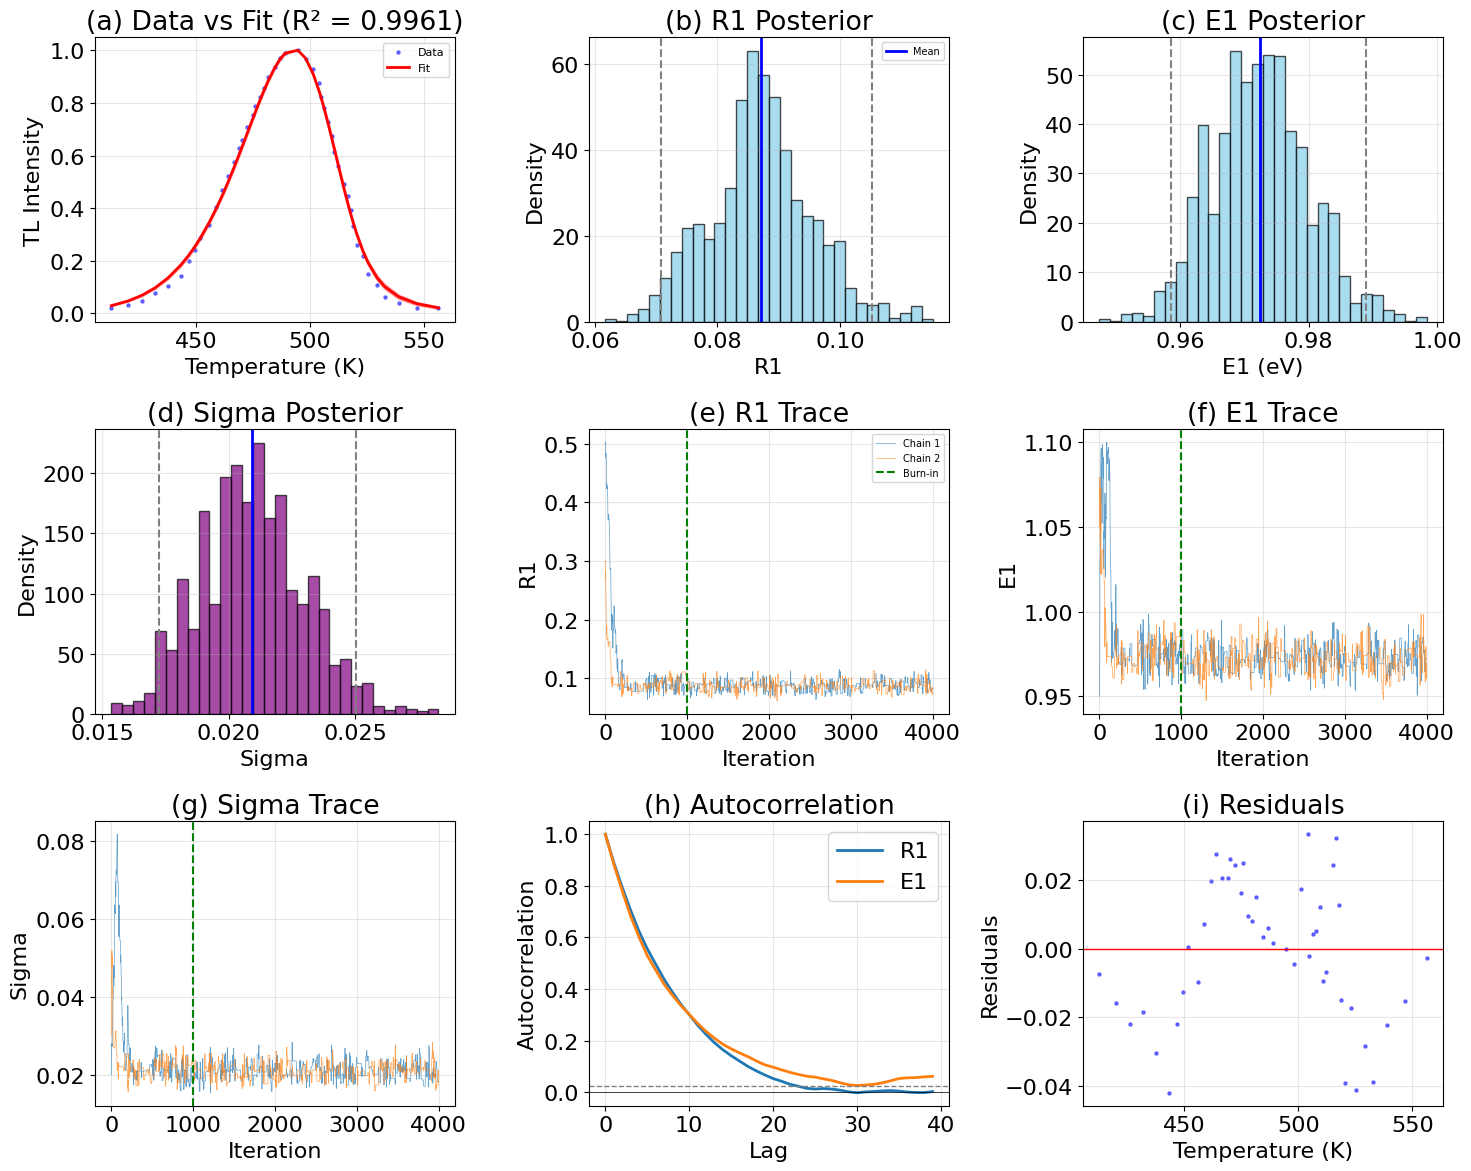


FINAL ESTIMATES
R1: 0.0871 ± 0.0085  [95% HPD: 0.0708, 0.1052]
E1: 0.9724 ± 0.0076  [95% HPD: 0.9585, 0.9889]
sigma: 0.0209 ± 0.0021  [95% HPD: 0.0172, 0.0251]

Acceptance rate: 0.126


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# =============================================================================
# DATA LOADING AND SETUP
# =============================================================================

np.random.seed(142)
plt.rcParams["font.size"] = 16

def readData():
    """Read TL data from GitHub."""
    url = 'https://github.com/vpagonis/Python-Codes/raw/main/Ch3PagonisGitHub/aluminaTLshort.TXT'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy() + 273.15  # temperature in Kelvin
    y_data = df.iloc[:, 1].to_numpy()

    # Normalize
    y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5

# Fixed parameters
FIXED_Imax = 1.0
FIXED_Tmax = Tmax_data

# Preliminary estimates
LS_estimates = {'R1': 0.15, 'E1': 1.0, 'sigma': 0.01}
LS_uncertainties = {'R1': 0.03, 'E1': 0.05, 'sigma': 0.001}

FIXED_Imax1 = 1.0
FIXED_Tmax1 = Tmax_data

print("="*60)
print("PYMC MODEL FOR SINGLE PEAK TL DATA - METROPOLIS SAMPLING")
print("="*60)
print("\nFixed parameters:")
print(f"  Imax1: {FIXED_Imax1:.2f}")
print(f"  Tmax1: {FIXED_Tmax1:.2f} K")

print("\nLeast squares estimates (used for prior means):")
print(f"  R1: {LS_estimates['R1']:.3f} ± {LS_uncertainties['R1']:.3f}")
print(f"  E1: {LS_estimates['E1']:.3f} ± {LS_uncertainties['E1']:.3f} eV")
print(f"  sigma: {LS_estimates['sigma']:.3f} ± {LS_uncertainties['sigma']:.3f}")

# =============================================================================
# VECTORIZED TL FUNCTION (NUMPY ONLY)
# =============================================================================

# Pre-compute constants for vectorized calculation
T = x_data
T2 = T**2
Tmax = FIXED_Tmax1
Tmax2 = Tmax**2
eps = 1e-10

# Pre-compute temperature-dependent values
kT_eps = kB * T + eps
kTmax_eps = kB * Tmax + eps

def tl_curve_numpy(R, E):
    """
    NumPy-based TL calculation.
    R and E are scalar values.
    """
    # Peak calculation
    exp_arg = -E / kT_eps
    exp_val = np.exp(exp_arg)

    F = kB * T2 * exp_val * (1 - 2*kB*T/(E + eps)) / (E + eps)

    exp_arg_m = -E / kTmax_eps
    exp_val_m = np.exp(exp_arg_m)
    Fm = kB * Tmax2 * exp_val_m * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)

    a = kB * Tmax2 * (1 - 1.05 * R**1.26) + eps
    term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
    exp_term = np.exp(E / kTmax_eps)

    Z = term1 + (F * E * exp_term) / a
    Zm = term1 + (Fm * E * exp_term) / a

    Z = np.clip(Z, -500, 500)
    Zm = np.clip(Zm, -500, 500)

    argW = np.log1p(np.exp(Z))
    argWm = np.log1p(np.exp(Zm))

    denominator = argW + argW**2 + eps

    result = FIXED_Imax1 * np.exp(-E/kT_eps * (Tmax - T)/Tmax) * (argWm + argWm**2) / denominator

    return np.where(np.isfinite(result), np.maximum(result, 0), 0)

def tl_curve_numpy_batch(params_batch):
    """
    Vectorized TL calculation for multiple parameter sets.
    params_batch: array of shape (n_samples, 3) with columns [R, E, sigma]
    Returns: array of shape (n_samples, n_temp)
    """
    if params_batch.ndim == 1:
        params_batch = params_batch.reshape(1, -1)

    n_samples = params_batch.shape[0]
    result = np.zeros((n_samples, len(T)))

    for i in range(n_samples):
        result[i] = tl_curve_numpy(params_batch[i, 0], params_batch[i, 1])

    return result

# =============================================================================
# SIMPLE METROPOLIS SAMPLER (NO PYMC FOR LIKELIHOOD)
# =============================================================================

# Beta parameters for R1
mu_R1 = LS_estimates['R1']
sigma_R1 = LS_uncertainties['R1']
var_R1 = sigma_R1**2
alpha_R1 = mu_R1 * (mu_R1 * (1 - mu_R1) / var_R1 - 1)
beta_R1 = (1 - mu_R1) * (mu_R1 * (1 - mu_R1) / var_R1 - 1)
alpha_R1 = max(alpha_R1, 1.01)
beta_R1 = max(beta_R1, 1.01)

# Prior functions
def log_prior(R, E, sigma):
    """Log prior probability."""
    if R <= 0 or R >= 1 or E < 0.8 or E > 1.1 or sigma <= 0:
        return -np.inf

    logp = (stats.beta.logpdf(R, alpha_R1, beta_R1) +
            stats.norm.logpdf(E, LS_estimates['E1'], LS_uncertainties['E1']*3) +
            stats.halfnorm.logpdf(sigma, scale=LS_estimates['sigma']*2))

    return logp

def log_likelihood(R, E, sigma):
    """Log likelihood."""
    mu = tl_curve_numpy(R, E)
    return np.sum(stats.norm.logpdf(y_data, mu, sigma))

def log_posterior(R, E, sigma):
    """Log posterior."""
    lp = log_prior(R, E, sigma)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(R, E, sigma)

def metropolis_sampler(n_iterations=3000, n_chains=2, tune=1000):
    """
    Simple Metropolis sampler.
    """
    param_names = ['R1', 'E1', 'sigma']
    n_params = 3

    # Proposal scales
    scales = np.array([0.02, 0.02, 0.005])

    # Initialize chains
    samples = np.zeros((n_chains, n_iterations + tune, n_params))
    acceptance = np.zeros((n_chains, n_iterations + tune))

    print("\nRunning Metropolis sampler...")

    for chain in range(n_chains):
        print(f"Evaluating chain {chain+1}")

        # Initialize
        if chain == 0:
            current = np.array([0.5, 0.95, 0.02])
        else:
            current = np.array([0.3, 1.05, 0.03])

        current_logp = log_posterior(current[0], current[1], current[2])

        for i in range(n_iterations + tune):
            # Store current
            samples[chain, i] = current

            # Propose new values (update all parameters at once for simplicity)
            proposal = current + np.random.normal(0, scales)

            # Check bounds
            if (proposal[0] <= 0 or proposal[0] >= 1 or
                proposal[1] < 0.8 or proposal[1] > 1.1 or
                proposal[2] <= 0):
                acceptance[chain, i] = 0
                continue

            # Compute log posterior for proposal
            proposal_logp = log_posterior(proposal[0], proposal[1], proposal[2])

            # Metropolis acceptance
            if np.log(np.random.random()) < proposal_logp - current_logp:
                current = proposal
                current_logp = proposal_logp
                acceptance[chain, i] = 1
            else:
                acceptance[chain, i] = 0

        print(f"  Chain {chain+1} acceptance rate: {np.mean(acceptance[chain]):.3f}")

    return samples, acceptance, param_names

# Run sampler
samples, acceptance, param_names = metropolis_sampler(n_iterations=3000, n_chains=2, tune=1000)

# Process samples
n_tune = 1000
samples_after_burnin = samples[:, n_tune:, :]
samples_flat = samples_after_burnin.reshape(-1, 3)

# Calculate statistics
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)
hpd_lower = np.percentile(samples_flat, 2.5, axis=0)
hpd_upper = np.percentile(samples_flat, 97.5, axis=0)

# Print summary
print("\n" + "="*80)
print("PARAMETER SUMMARY")
print("="*80)
print(f"{'Parameter':<8} {'Mean':<10} {'Std':<10} {'95% HPD Lower':<15} {'95% HPD Upper':<15}")
print("-"*60)
for i, name in enumerate(param_names):
    print(f"{name:<8} {means[i]:<10.4f} {stds[i]:<10.4f} {hpd_lower[i]:<15.4f} {hpd_upper[i]:<15.4f}")

# =============================================================================
# CALCULATE FIT
# =============================================================================

print("\nCalculating fit statistics...")
n_fit = min(500, len(samples_flat))
indices = np.random.choice(len(samples_flat), n_fit, replace=False)
mu_samples = tl_curve_numpy_batch(samples_flat[indices])

mu_mean = np.mean(mu_samples, axis=0)
mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

# Calculate R-squared
residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"\nR-squared: {r_squared:.4f}")

# =============================================================================
# PLOTTING
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Plot 1: Data vs Fit
ax = axes[0, 0]
ax.scatter(x_data, y_data, s=5, alpha=0.5, color='blue', label='Data')
ax.plot(x_data, mu_mean, 'r-', linewidth=2, label='Fit')
ax.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3, color='red')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('TL Intensity')
ax.set_title(f'(a) Data vs Fit (R² = {r_squared:.4f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: R1 Posterior
ax = axes[0, 1]
ax.hist(samples_flat[:, 0], bins=30, density=True, alpha=0.7,
        color='skyblue', edgecolor='black')
ax.axvline(means[0], color='blue', linewidth=2, label='Mean')
ax.axvline(hpd_lower[0], color='gray', linestyle='--')
ax.axvline(hpd_upper[0], color='gray', linestyle='--')
ax.set_xlabel('R1')
ax.set_ylabel('Density')
ax.set_title('(b) R1 Posterior')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 3: E1 Posterior
ax = axes[0, 2]
ax.hist(samples_flat[:, 1], bins=30, density=True, alpha=0.7,
        color='skyblue', edgecolor='black')
ax.axvline(means[1], color='blue', linewidth=2)
ax.axvline(hpd_lower[1], color='gray', linestyle='--')
ax.axvline(hpd_upper[1], color='gray', linestyle='--')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Density')
ax.set_title('(c) E1 Posterior')
ax.grid(True, alpha=0.3)

# Plot 4: Sigma Posterior
ax = axes[1, 0]
ax.hist(samples_flat[:, 2], bins=30, density=True, alpha=0.7,
        color='purple', edgecolor='black')
ax.axvline(means[2], color='blue', linewidth=2)
ax.axvline(hpd_lower[2], color='gray', linestyle='--')
ax.axvline(hpd_upper[2], color='gray', linestyle='--')
ax.set_xlabel('Sigma')
ax.set_ylabel('Density')
ax.set_title('(d) Sigma Posterior')
ax.grid(True, alpha=0.3)

# Plot 5: R1 Trace
ax = axes[1, 1]
for chain in range(2):
    ax.plot(samples[chain, :, 0], alpha=0.7, linewidth=0.5, label=f'Chain {chain+1}')
ax.axvline(1000, color='green', linestyle='--', label='Burn-in')
ax.set_xlabel('Iteration')
ax.set_ylabel('R1')
ax.set_title('(e) R1 Trace')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 6: E1 Trace
ax = axes[1, 2]
for chain in range(2):
    ax.plot(samples[chain, :, 1], alpha=0.7, linewidth=0.5)
ax.axvline(1000, color='green', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('E1')
ax.set_title('(f) E1 Trace')
ax.grid(True, alpha=0.3)

# Plot 7: Sigma Trace
ax = axes[2, 0]
for chain in range(2):
    ax.plot(samples[chain, :, 2], alpha=0.7, linewidth=0.5)
ax.axvline(1000, color='green', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('Sigma')
ax.set_title('(g) Sigma Trace')
ax.grid(True, alpha=0.3)

# Plot 8: Autocorrelation
ax = axes[2, 1]
lags = 40
for i, name in enumerate(['R1', 'E1']):
    samples_param = samples_flat[:, i]
    n = len(samples_param)
    samples_centered = samples_param - np.mean(samples_param)
    acf = np.correlate(samples_centered, samples_centered, mode='full') / np.var(samples_param)
    acf = acf[n-1:n-1+lags] / (n - np.arange(lags))
    ax.plot(range(lags), acf, label=name, linewidth=2)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=1.96/np.sqrt(len(samples_flat)), color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title('(h) Autocorrelation')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 9: Residuals
ax = axes[2, 2]
ax.scatter(x_data, residuals, s=5, alpha=0.5, color='blue')
ax.axhline(0, color='red', linewidth=1)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Residuals')
ax.set_title('(i) Residuals')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print("FINAL ESTIMATES")
print("="*60)
for i, name in enumerate(param_names):
    print(f"{name}: {means[i]:.4f} ± {stds[i]:.4f}  [95% HPD: {hpd_lower[i]:.4f}, {hpd_upper[i]:.4f}]")

print(f"\nAcceptance rate: {np.mean(acceptance):.3f}")

# Save results
results_df = pd.DataFrame({
    'Parameter': param_names,
    'Mean': means,
    'Std': stds,
    'HDI_2.5%': hpd_lower,
    'HDI_97.5%': hpd_upper
})
# results_df.to_csv('metropolis_results.csv', index=False)
# print("\n✓ Results saved to 'metropolis_results.csv'")
# @
# @

**Code 2** Metropolis algorithm double peak TL glow curve

CUSTOM METROPOLIS SAMPLER FOR 2-PEAK TL DATA

Fixed parameters:
  Peak 1: Imax1=119.42, Tmax1=462.75 K
  Peak 2: Imax2=19.85, Tmax2=523.38 K

Least squares estimates (used for prior means):
  R1: 0.150 ± 0.030
  E1: 1.220 ± 0.050 eV
  R2: 0.550 ± 0.040
  E2: 1.610 ± 0.060 eV
  sigma: 4.800 ± 0.500

R1 Beta prior: alpha=21.10, beta=119.57
R2 Beta prior: alpha=84.53, beta=69.16

Running Metropolis sampler for 2 peaks...
Evaluating chain 1
  Chain 1 acceptance rate: 0.828
Evaluating chain 2
  Chain 2 acceptance rate: 0.817
Evaluating chain 3
  Chain 3 acceptance rate: 0.815
Evaluating chain 4
  Chain 4 acceptance rate: 0.821

PARAMETER SUMMARY - 2-PEAK METROPOLIS SAMPLER
Parameter Mean       Std        95% HPD Lower   95% HPD Upper  
------------------------------------------------------------
R1       0.1605     0.0515     0.0743          0.2733         
E1       1.2549     0.0622     1.1498          1.3815         
R2       0.5392     0.0389     0.4644          0.6146         
E2       

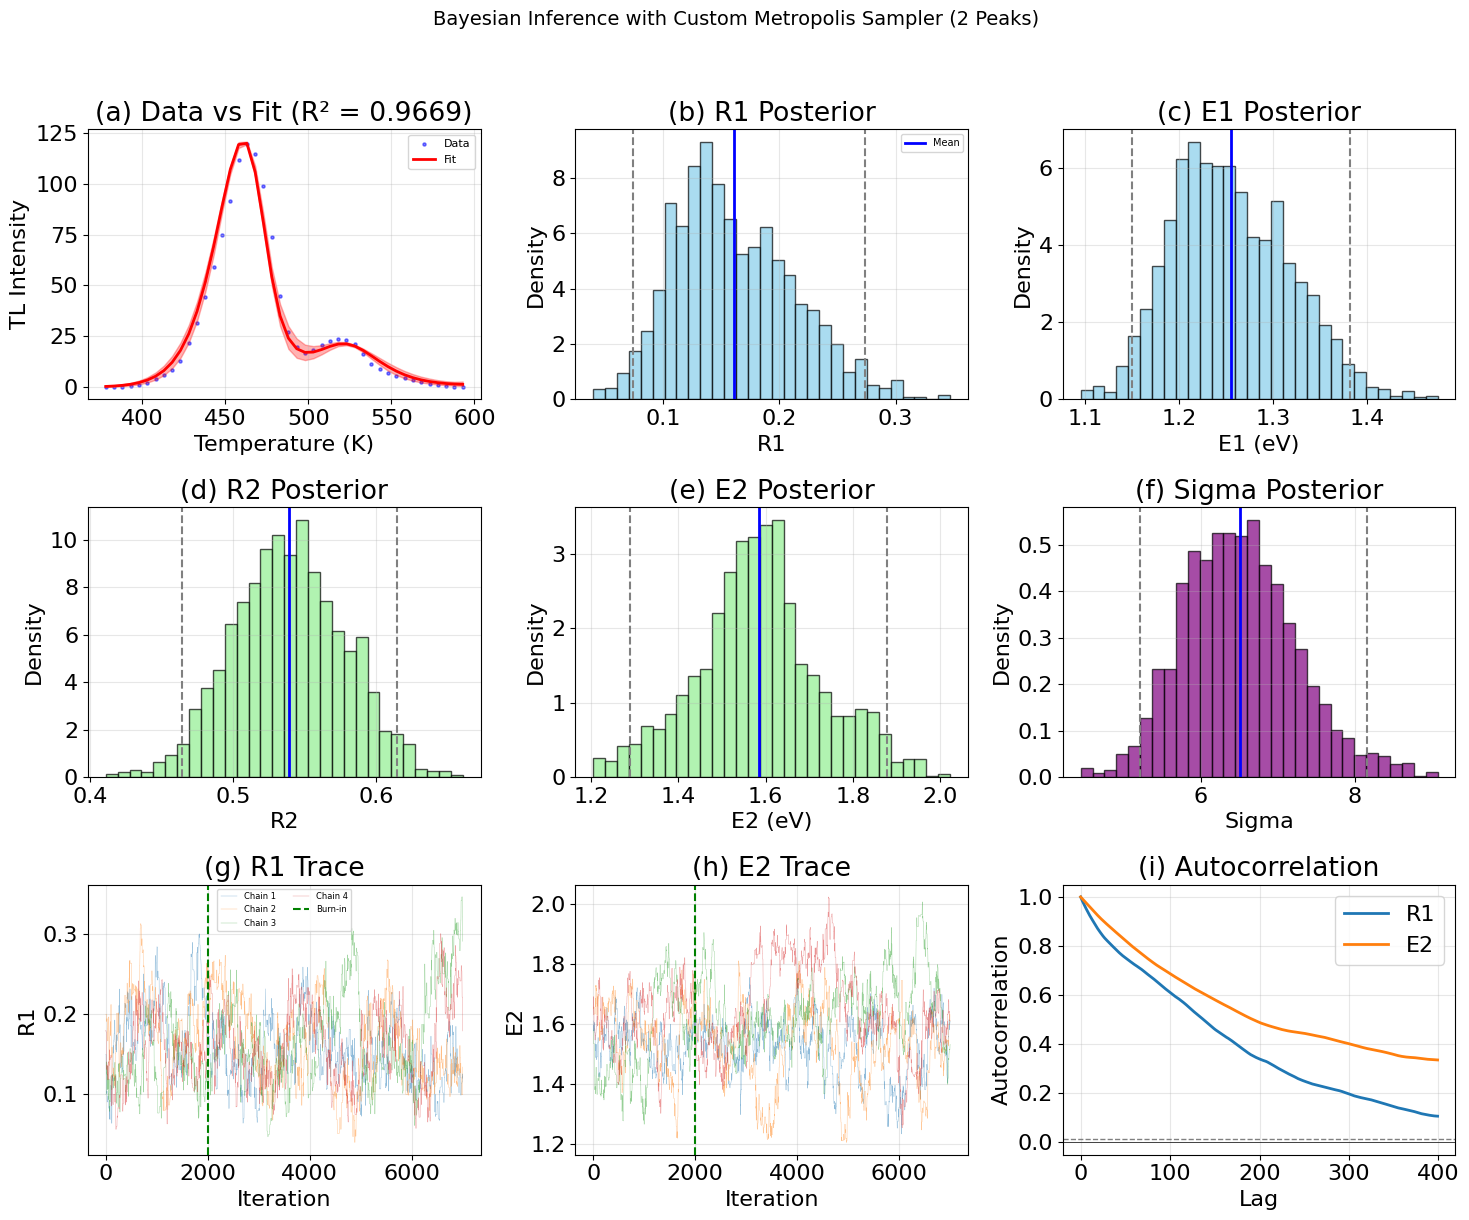

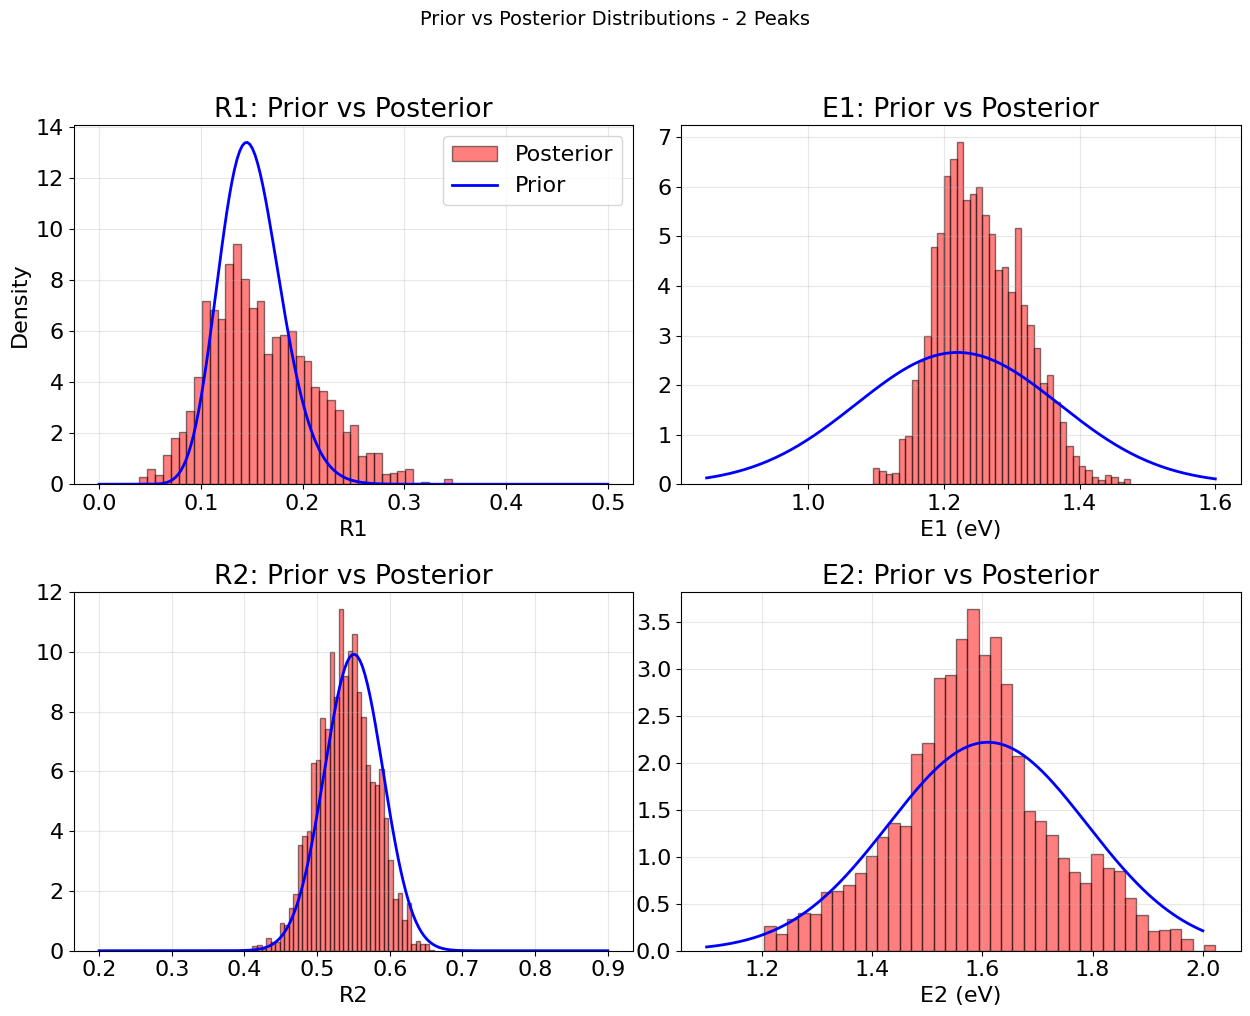


FINAL ESTIMATES - 2 PEAKS
R1: 0.1605 ± 0.0515  [95% HPD: 0.0743, 0.2733]
E1: 1.2549 ± 0.0622  [95% HPD: 1.1498, 1.3815]
R2: 0.5392 ± 0.0389  [95% HPD: 0.4644, 0.6146]
E2: 1.5850 ± 0.1440  [95% HPD: 1.2896, 1.8782]
sigma: 6.5072 ± 0.7352  [95% HPD: 5.2222, 8.1560]


In [ ]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import pandas as pd


# =============================================================================
# DATA LOADING AND SETUP
# =============================================================================

np.random.seed(42)
plt.rcParams["font.size"] = 16

def readData():
    """Read TL data from GitHub."""
    url = 'https://raw.githubusercontent.com/vpagonis/Python-Codes/refs/heads/main/Ch3PagonisGitHub/lbodata.txt'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy()   # temperature in Kelvin
    y_data = df.iloc[:, 1].to_numpy()

    # Normalize
    # y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5

# Fixed parameters for two peaks (from previous analysis)
FIXED_Imax1 = 119.42
FIXED_Tmax1 = 462.75
FIXED_Imax2 = 19.85
FIXED_Tmax2 = 523.38

# Preliminary estimates
LS_estimates = {
    'R1': 0.15, 'E1': 1.22,
    'R2': 0.55, 'E2': 1.61,
    'sigma': 4.8
}

LS_uncertainties = {
    'R1': 0.03, 'E1': 0.05,
    'R2': 0.04, 'E2': 0.06,
    'sigma': 0.5
}

print("="*60)
print("CUSTOM METROPOLIS SAMPLER FOR 2-PEAK TL DATA")
print("="*60)
print("\nFixed parameters:")
print(f"  Peak 1: Imax1={FIXED_Imax1:.2f}, Tmax1={FIXED_Tmax1:.2f} K")
print(f"  Peak 2: Imax2={FIXED_Imax2:.2f}, Tmax2={FIXED_Tmax2:.2f} K")

print("\nLeast squares estimates (used for prior means):")
print(f"  R1: {LS_estimates['R1']:.3f} ± {LS_uncertainties['R1']:.3f}")
print(f"  E1: {LS_estimates['E1']:.3f} ± {LS_uncertainties['E1']:.3f} eV")
print(f"  R2: {LS_estimates['R2']:.3f} ± {LS_uncertainties['R2']:.3f}")
print(f"  E2: {LS_estimates['E2']:.3f} ± {LS_uncertainties['E2']:.3f} eV")
print(f"  sigma: {LS_estimates['sigma']:.3f} ± {LS_uncertainties['sigma']:.3f}")

# =============================================================================
# VECTORIZED TL FUNCTION FOR 2 PEAKS (NUMPY ONLY)
# =============================================================================

# Pre-compute constants
T = x_data
T2 = T**2
eps = 1e-10

# Pre-compute peak-specific constants
peak_constants = [
    {'Imax': FIXED_Imax1, 'Tmax': FIXED_Tmax1, 'Tmax2': FIXED_Tmax1**2},
    {'Imax': FIXED_Imax2, 'Tmax': FIXED_Tmax2, 'Tmax2': FIXED_Tmax2**2}
]

# Pre-compute temperature-dependent values for each peak
kT_eps = kB * T + eps
kTmax_eps_1 = kB * FIXED_Tmax1 + eps
kTmax_eps_2 = kB * FIXED_Tmax2 + eps

def tl_peak_numpy(R, E, peak_idx):
    """
    Calculate TL for a single peak.
    """
    const = peak_constants[peak_idx]
    Imax = const['Imax']
    Tmax = const['Tmax']
    Tmax2 = const['Tmax2']
    kTmax_eps = kB * Tmax + eps

    exp_arg = -E / kT_eps
    exp_val = np.exp(exp_arg)

    F = kB * T2 * exp_val * (1 - 2*kB*T/(E + eps)) / (E + eps)

    exp_arg_m = -E / kTmax_eps
    exp_val_m = np.exp(exp_arg_m)
    Fm = kB * Tmax2 * exp_val_m * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)

    a = kB * Tmax2 * (1 - 1.05 * R**1.26) + eps
    term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
    exp_term = np.exp(E / kTmax_eps)

    Z = term1 + (F * E * exp_term) / a
    Zm = term1 + (Fm * E * exp_term) / a

    Z = np.clip(Z, -500, 500)
    Zm = np.clip(Zm, -500, 500)

    argW = np.log1p(np.exp(Z))
    argWm = np.log1p(np.exp(Zm))

    denominator = argW + argW**2 + eps

    result = Imax * np.exp(-E/kT_eps * (Tmax - T)/Tmax) * (argWm + argWm**2) / denominator

    return np.where(np.isfinite(result), np.maximum(result, 0), 0)

def tl_curve_numpy(R1, E1, R2, E2):
    """
    Calculate total TL for both peaks.
    """
    return tl_peak_numpy(R1, E1, 0) + tl_peak_numpy(R2, E2, 1)

def tl_curve_numpy_batch(params_batch):
    """
    Vectorized TL calculation for multiple parameter sets.
    params_batch: array of shape (n_samples, 5) [R1, E1, R2, E2, sigma]
    Returns: array of shape (n_samples, n_temp)
    """
    if params_batch.ndim == 1:
        params_batch = params_batch.reshape(1, -1)

    n_samples = params_batch.shape[0]
    result = np.zeros((n_samples, len(T)))

    for i in range(n_samples):
        result[i] = tl_curve_numpy(params_batch[i, 0], params_batch[i, 1],
                                   params_batch[i, 2], params_batch[i, 3])

    return result

# =============================================================================
# PRIOR DISTRIBUTIONS FOR 2 PEAKS
# =============================================================================

def beta_params(mu, sigma):
    var = sigma**2
    alpha = mu * (mu * (1 - mu) / var - 1)
    beta = (1 - mu) * (mu * (1 - mu) / var - 1)
    return max(alpha, 1.5), max(beta, 1.5)

# Beta parameters for R1 and R2
alpha_R1, beta_R1 = beta_params(LS_estimates['R1'], LS_uncertainties['R1'])
alpha_R2, beta_R2 = beta_params(LS_estimates['R2'], LS_uncertainties['R2'])

print(f"\nR1 Beta prior: alpha={alpha_R1:.2f}, beta={beta_R1:.2f}")
print(f"R2 Beta prior: alpha={alpha_R2:.2f}, beta={beta_R2:.2f}")

def log_prior(R1, E1, R2, E2, sigma):
    """Log prior probability for 2 peaks."""
    # Check bounds
    if (R1 <= 0 or R1 >= 1 or R2 <= 0 or R2 >= 1 or
        E1 < 1.0 or E1 > 1.8 or E2 < 1.2 or E2 > 2.2 or
        sigma <= 0):
        return -np.inf

    logp = (stats.beta.logpdf(R1, alpha_R1, beta_R1) +
            stats.norm.logpdf(E1, LS_estimates['E1'], LS_uncertainties['E1']*3) +
            stats.beta.logpdf(R2, alpha_R2, beta_R2) +
            stats.norm.logpdf(E2, LS_estimates['E2'], LS_uncertainties['E2']*3) +
            stats.halfnorm.logpdf(sigma, scale=LS_estimates['sigma']*2))

    return logp

def log_likelihood(R1, E1, R2, E2, sigma):
    """Log likelihood for 2 peaks."""
    mu = tl_curve_numpy(R1, E1, R2, E2)
    return np.sum(stats.norm.logpdf(y_data, mu, sigma))

def log_posterior(R1, E1, R2, E2, sigma):
    """Log posterior for 2 peaks."""
    lp = log_prior(R1, E1, R2, E2, sigma)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(R1, E1, R2, E2, sigma)

# =============================================================================
# METROPOLIS SAMPLER FOR 2 PEAKS
# =============================================================================

def metropolis_sampler_2peaks(n_iterations=5000, n_chains=4, tune=2000):
    """
    Metropolis sampler for 2-peak TL data.
    """
    param_names = ['R1', 'E1', 'R2', 'E2', 'sigma']
    n_params = 5

    # Proposal scales (tuned manually for each parameter)
    scales = np.array([0.02, 0.03, 0.02, 0.03, 0.5])

    # Parameter bounds
    lower_bounds = np.array([0.01, 1.0, 0.01, 1.2, 0.1])
    upper_bounds = np.array([0.99, 1.8, 0.99, 2.2, 20.0])

    # Initialize chains
    samples = np.zeros((n_chains, n_iterations + tune, n_params))
    acceptance = np.zeros((n_chains, n_iterations + tune))

    print("\nRunning Metropolis sampler for 2 peaks...")

    # Different starting points for each chain
    start_points = [
        np.array([0.15, 1.22, 0.55, 1.61, 4.8]),   # Chain 1: LS estimates
        np.array([0.20, 1.18, 0.50, 1.65, 5.0]),   # Chain 2: perturbed
        np.array([0.10, 1.25, 0.60, 1.58, 4.5]),   # Chain 3: perturbed
        np.array([0.18, 1.20, 0.52, 1.63, 5.2])    # Chain 4: perturbed
    ]

    for chain in range(n_chains):
        print(f"Evaluating chain {chain+1}")

        # Initialize
        current = start_points[chain].copy()
        current_logp = log_posterior(current[0], current[1], current[2], current[3], current[4])

        for i in range(n_iterations + tune):
            # Store current
            samples[chain, i] = current

            # Randomly choose parameter to update
            param_idx = np.random.randint(n_params)

            # Propose new value
            proposal = current.copy()
            proposal[param_idx] = current[param_idx] + np.random.normal(0, scales[param_idx])

            # Check bounds
            if (proposal[param_idx] < lower_bounds[param_idx] or
                proposal[param_idx] > upper_bounds[param_idx]):
                acceptance[chain, i] = 0
                continue

            # Compute log posterior for proposal
            proposal_logp = log_posterior(proposal[0], proposal[1], proposal[2],
                                         proposal[3], proposal[4])

            # Metropolis acceptance
            if np.log(np.random.random()) < proposal_logp - current_logp:
                current = proposal
                current_logp = proposal_logp
                acceptance[chain, i] = 1
            else:
                acceptance[chain, i] = 0

        chain_acc = np.mean(acceptance[chain])
        print(f"  Chain {chain+1} acceptance rate: {chain_acc:.3f}")

    return samples, acceptance, param_names

# Run sampler
samples, acceptance, param_names = metropolis_sampler_2peaks(n_iterations=5000, n_chains=4, tune=2000)

# Process samples
n_tune = 2000
samples_after_burnin = samples[:, n_tune:, :]
samples_flat = samples_after_burnin.reshape(-1, 5)

# Calculate statistics
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)
hpd_lower = np.percentile(samples_flat, 2.5, axis=0)
hpd_upper = np.percentile(samples_flat, 97.5, axis=0)

# Print summary
print("\n" + "="*80)
print("PARAMETER SUMMARY - 2-PEAK METROPOLIS SAMPLER")
print("="*80)
print(f"{'Parameter':<8} {'Mean':<10} {'Std':<10} {'95% HPD Lower':<15} {'95% HPD Upper':<15}")
print("-"*60)
for i, name in enumerate(param_names):
    print(f"{name:<8} {means[i]:<10.4f} {stds[i]:<10.4f} {hpd_lower[i]:<15.4f} {hpd_upper[i]:<15.4f}")

# =============================================================================
# CALCULATE FIT
# =============================================================================

print("\nCalculating fit statistics...")
n_fit = min(500, len(samples_flat))
indices = np.random.choice(len(samples_flat), n_fit, replace=False)
mu_samples = tl_curve_numpy_batch(samples_flat[indices])

mu_mean = np.mean(mu_samples, axis=0)
mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

# Calculate fit statistics
residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
n = len(y_data)
p = 4
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
rmse = np.sqrt(np.mean(residuals**2))
fom = np.sum(np.abs(residuals)) / np.sum(mu_mean) * 100

print(f"\nR-squared: {r_squared:.4f}")
print(f"Adj R-squared: {adj_r_squared:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"FOM: {fom:.2f}%")
print(f"Average acceptance rate: {np.mean(acceptance):.3f}")

# =============================================================================
# PLOTTING
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Plot 1: Data vs Fit
ax = axes[0, 0]
ax.scatter(x_data, y_data, s=5, alpha=0.5, color='blue', label='Data')
ax.plot(x_data, mu_mean, 'r-', linewidth=2, label='Fit')
ax.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3, color='red')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('TL Intensity')
ax.set_title(f'(a) Data vs Fit (R² = {r_squared:.4f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: R1 Posterior
ax = axes[0, 1]
ax.hist(samples_flat[:, 0], bins=30, density=True, alpha=0.7,
        color='skyblue', edgecolor='black')
ax.axvline(means[0], color='blue', linewidth=2, label='Mean')
ax.axvline(hpd_lower[0], color='gray', linestyle='--')
ax.axvline(hpd_upper[0], color='gray', linestyle='--')
ax.set_xlabel('R1')
ax.set_ylabel('Density')
ax.set_title('(b) R1 Posterior')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 3: E1 Posterior
ax = axes[0, 2]
ax.hist(samples_flat[:, 1], bins=30, density=True, alpha=0.7,
        color='skyblue', edgecolor='black')
ax.axvline(means[1], color='blue', linewidth=2)
ax.axvline(hpd_lower[1], color='gray', linestyle='--')
ax.axvline(hpd_upper[1], color='gray', linestyle='--')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Density')
ax.set_title('(c) E1 Posterior')
ax.grid(True, alpha=0.3)

# Plot 4: R2 Posterior
ax = axes[1, 0]
ax.hist(samples_flat[:, 2], bins=30, density=True, alpha=0.7,
        color='lightgreen', edgecolor='black')
ax.axvline(means[2], color='blue', linewidth=2)
ax.axvline(hpd_lower[2], color='gray', linestyle='--')
ax.axvline(hpd_upper[2], color='gray', linestyle='--')
ax.set_xlabel('R2')
ax.set_ylabel('Density')
ax.set_title('(d) R2 Posterior')
ax.grid(True, alpha=0.3)

# Plot 5: E2 Posterior
ax = axes[1, 1]
ax.hist(samples_flat[:, 3], bins=30, density=True, alpha=0.7,
        color='lightgreen', edgecolor='black')
ax.axvline(means[3], color='blue', linewidth=2)
ax.axvline(hpd_lower[3], color='gray', linestyle='--')
ax.axvline(hpd_upper[3], color='gray', linestyle='--')
ax.set_xlabel('E2 (eV)')
ax.set_ylabel('Density')
ax.set_title('(e) E2 Posterior')
ax.grid(True, alpha=0.3)

# Plot 6: Sigma Posterior
ax = axes[1, 2]
ax.hist(samples_flat[:, 4], bins=30, density=True, alpha=0.7,
        color='purple', edgecolor='black')
ax.axvline(means[4], color='blue', linewidth=2)
ax.axvline(hpd_lower[4], color='gray', linestyle='--')
ax.axvline(hpd_upper[4], color='gray', linestyle='--')
ax.set_xlabel('Sigma')
ax.set_ylabel('Density')
ax.set_title('(f) Sigma Posterior')
ax.grid(True, alpha=0.3)

# Plot 7: R1 Trace
ax = axes[2, 0]
for chain in range(4):
    ax.plot(samples[chain, :, 0], alpha=0.5, linewidth=0.3, label=f'Chain {chain+1}')
ax.axvline(2000, color='green', linestyle='--', label='Burn-in')
ax.set_xlabel('Iteration')
ax.set_ylabel('R1')
ax.set_title('(g) R1 Trace')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# Plot 8: E2 Trace
ax = axes[2, 1]
for chain in range(4):
    ax.plot(samples[chain, :, 3], alpha=0.5, linewidth=0.3)
ax.axvline(2000, color='green', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('E2')
ax.set_title('(h) E2 Trace')
ax.grid(True, alpha=0.3)

# Plot 9: Autocorrelation
ax = axes[2, 2]
lags = 400
for i, name in enumerate(['R1', 'E2']):
    idx = 0 if name == 'R1' else 3
    samples_param = samples_flat[:, idx]
    n = len(samples_param)
    samples_centered = samples_param - np.mean(samples_param)
    acf = np.correlate(samples_centered, samples_centered, mode='full') / np.var(samples_param)
    acf = acf[n-1:n-1+lags] / (n - np.arange(lags))
    ax.plot(range(lags), acf, label=name, linewidth=2)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=1.96/np.sqrt(len(samples_flat)), color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title('(i) Autocorrelation')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Bayesian Inference with Custom Metropolis Sampler (2 Peaks)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# PRIOR VS POSTERIOR COMPARISON
# =============================================================================

fig_prior, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# R1
ax = axes[0]
x = np.linspace(0, 0.5, 200)
prior = stats.beta.pdf(x, alpha_R1, beta_R1)
ax.hist(samples_flat[:, 0], bins=40, density=True, alpha=0.5, color='red',
        edgecolor='black', label='Posterior')
ax.plot(x, prior, 'b-', linewidth=2, label='Prior')
ax.set_xlabel('R1'), ax.set_ylabel('Density'), ax.set_title('R1: Prior vs Posterior')
ax.legend(), ax.grid(True, alpha=0.3)

# E1
ax = axes[1]
x = np.linspace(.85, 1.6, 200)
prior = stats.norm.pdf(x, LS_estimates['E1'], LS_uncertainties['E1']*3)
ax.hist(samples_flat[:, 1], bins=40, density=True, alpha=0.5, color='red', edgecolor='black')
ax.plot(x, prior, 'b-', linewidth=2)
ax.set_xlabel('E1 (eV)'), ax.set_title('E1: Prior vs Posterior')
ax.grid(True, alpha=0.3)

# R2
ax = axes[2]
x = np.linspace(0.2, 0.9, 200)
prior = stats.beta.pdf(x, alpha_R2, beta_R2)
ax.hist(samples_flat[:, 2], bins=40, density=True, alpha=0.5, color='red', edgecolor='black')
ax.plot(x, prior, 'b-', linewidth=2)
ax.set_xlabel('R2'), ax.set_title('R2: Prior vs Posterior')
ax.grid(True, alpha=0.3)

# E2
ax = axes[3]
x = np.linspace(1.1, 2.0, 200)
prior = stats.norm.pdf(x, LS_estimates['E2'], LS_uncertainties['E2']*3)
ax.hist(samples_flat[:, 3], bins=40, density=True, alpha=0.5, color='red', edgecolor='black')
ax.plot(x, prior, 'b-', linewidth=2)
ax.set_xlabel('E2 (eV)'), ax.set_title('E2: Prior vs Posterior')
ax.grid(True, alpha=0.3)

# # Sigma
# ax = axes[4]
# x = np.linspace(0, 15, 200)
# prior = stats.halfnorm.pdf(x, scale=LS_estimates['sigma']*2)
# ax.hist(samples_flat[:, 4], bins=40, density=True, alpha=0.5, color='red', edgecolor='black')
# ax.plot(x, prior, 'b-', linewidth=2)
# ax.set_xlabel('Sigma'), ax.set_title('Sigma: Prior vs Posterior')
# ax.grid(True, alpha=0.3)

# axes[5].set_visible(False)
plt.suptitle('Prior vs Posterior Distributions - 2 Peaks', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print("FINAL ESTIMATES - 2 PEAKS")
print("="*60)
for i, name in enumerate(param_names):
    print(f"{name}: {means[i]:.4f} ± {stds[i]:.4f}  [95% HPD: {hpd_lower[i]:.4f}, {hpd_upper[i]:.4f}]")

# Save results
results_df = pd.DataFrame({
    'Parameter': param_names,
    'Mean': means,
    'Std': stds,
    'HDI_2.5%': hpd_lower,
    'HDI_97.5%': hpd_upper
})
# results_df.to_csv('metropolis_2peaks_results.csv', index=False)
# print("\n✓ Results saved to 'metropolis_2peaks_results.csv'")
# @
# @

**Code 3** Metropolis code, 5 peaks, simulated data

SIMULATED DATA FOR 5-PEAK TL MODEL
Temperature range: 300-700 K
Number of data points: 200
True noise sigma: 2.5

True parameters used for simulation:
  Peak 1: R=0.150, E=1.220 eV, Imax=119.4, Tmax=462.8 K
  Peak 2: R=0.550, E=1.310 eV, Imax=19.9, Tmax=523.4 K
  Peak 3: R=0.350, E=1.450 eV, Imax=35.0, Tmax=590.0 K
  Peak 4: R=0.450, E=1.600 eV, Imax=25.0, Tmax=550.0 K
  Peak 5: R=0.250, E=1.700 eV, Imax=45.0, Tmax=610.0 K

Data simulation complete.
Data range: [0.00, 122.23]
Noise scale (10% of mean signal): 3.2625

Data simulation complete.
Data range: [0.00, 122.23]

Preliminary estimates (used for prior means):
  R1: 0.155 ± 0.030
  E1: 1.254 ± 0.050 eV
  R2: 0.610 ± 0.030
  E2: 1.379 ± 0.050 eV
  R3: 0.302 ± 0.030
  E3: 1.382 ± 0.050 eV
  R4: 0.473 ± 0.030
  E4: 1.641 ± 0.050 eV
  R5: 0.263 ± 0.030
  E5: 2.027 ± 0.050 eV
  sigma: 4.894 ± 0.500

Beta priors:
  R1: alpha=22.50, beta=122.31
  R2: alpha=160.58, beta=102.85
  R3: alpha=70.35, beta=162.77
  R4: alpha=130.59, beta=145.39

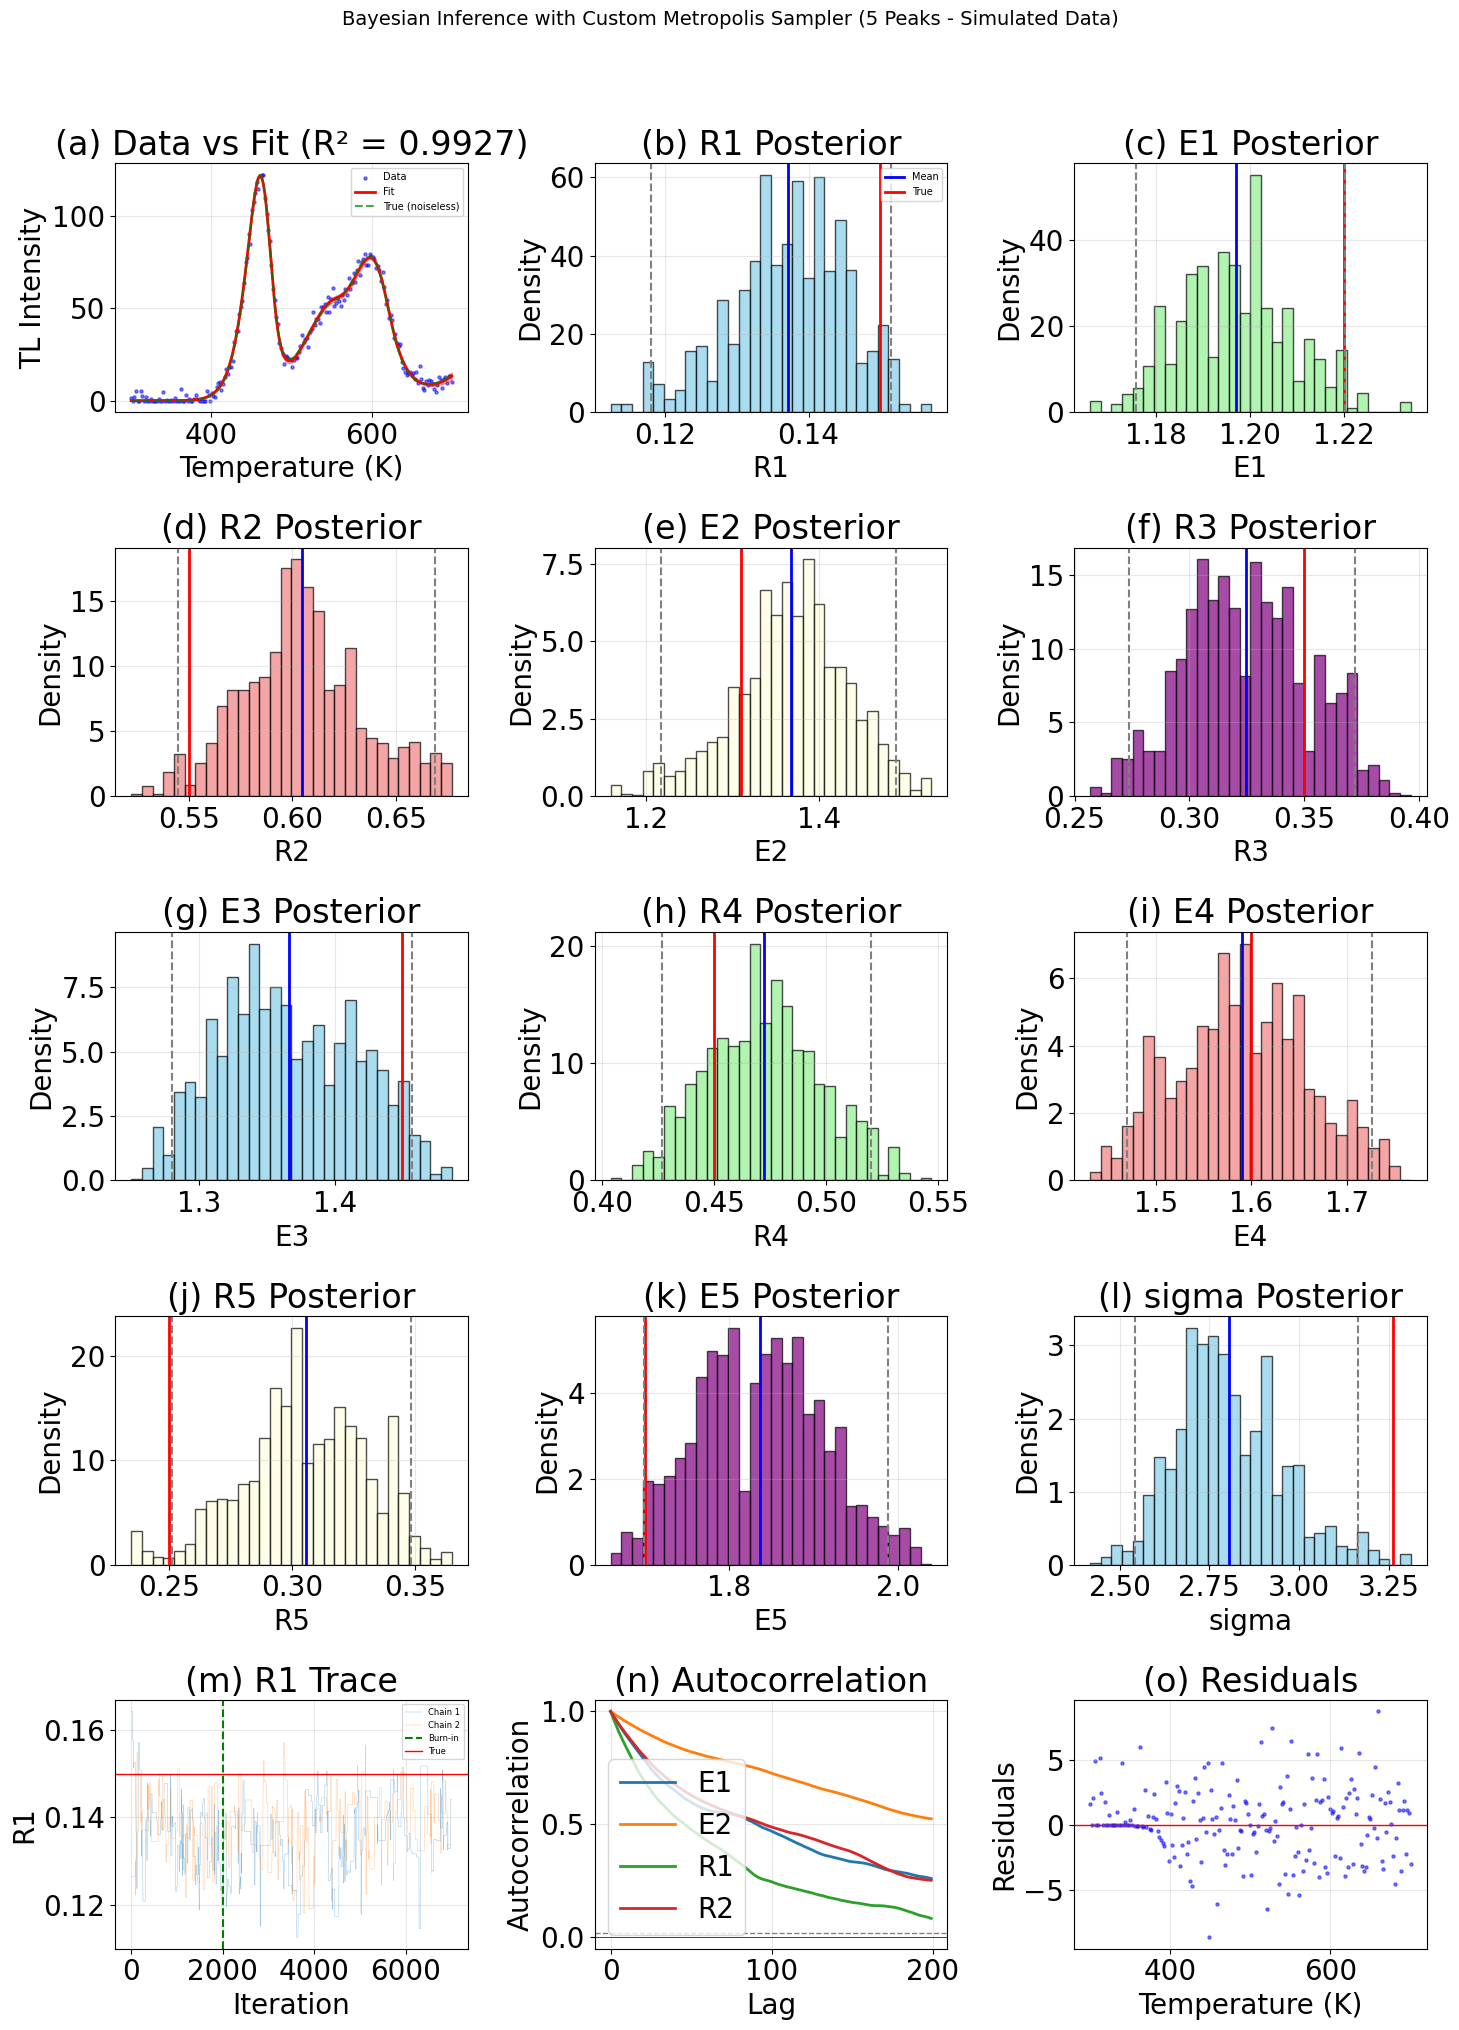

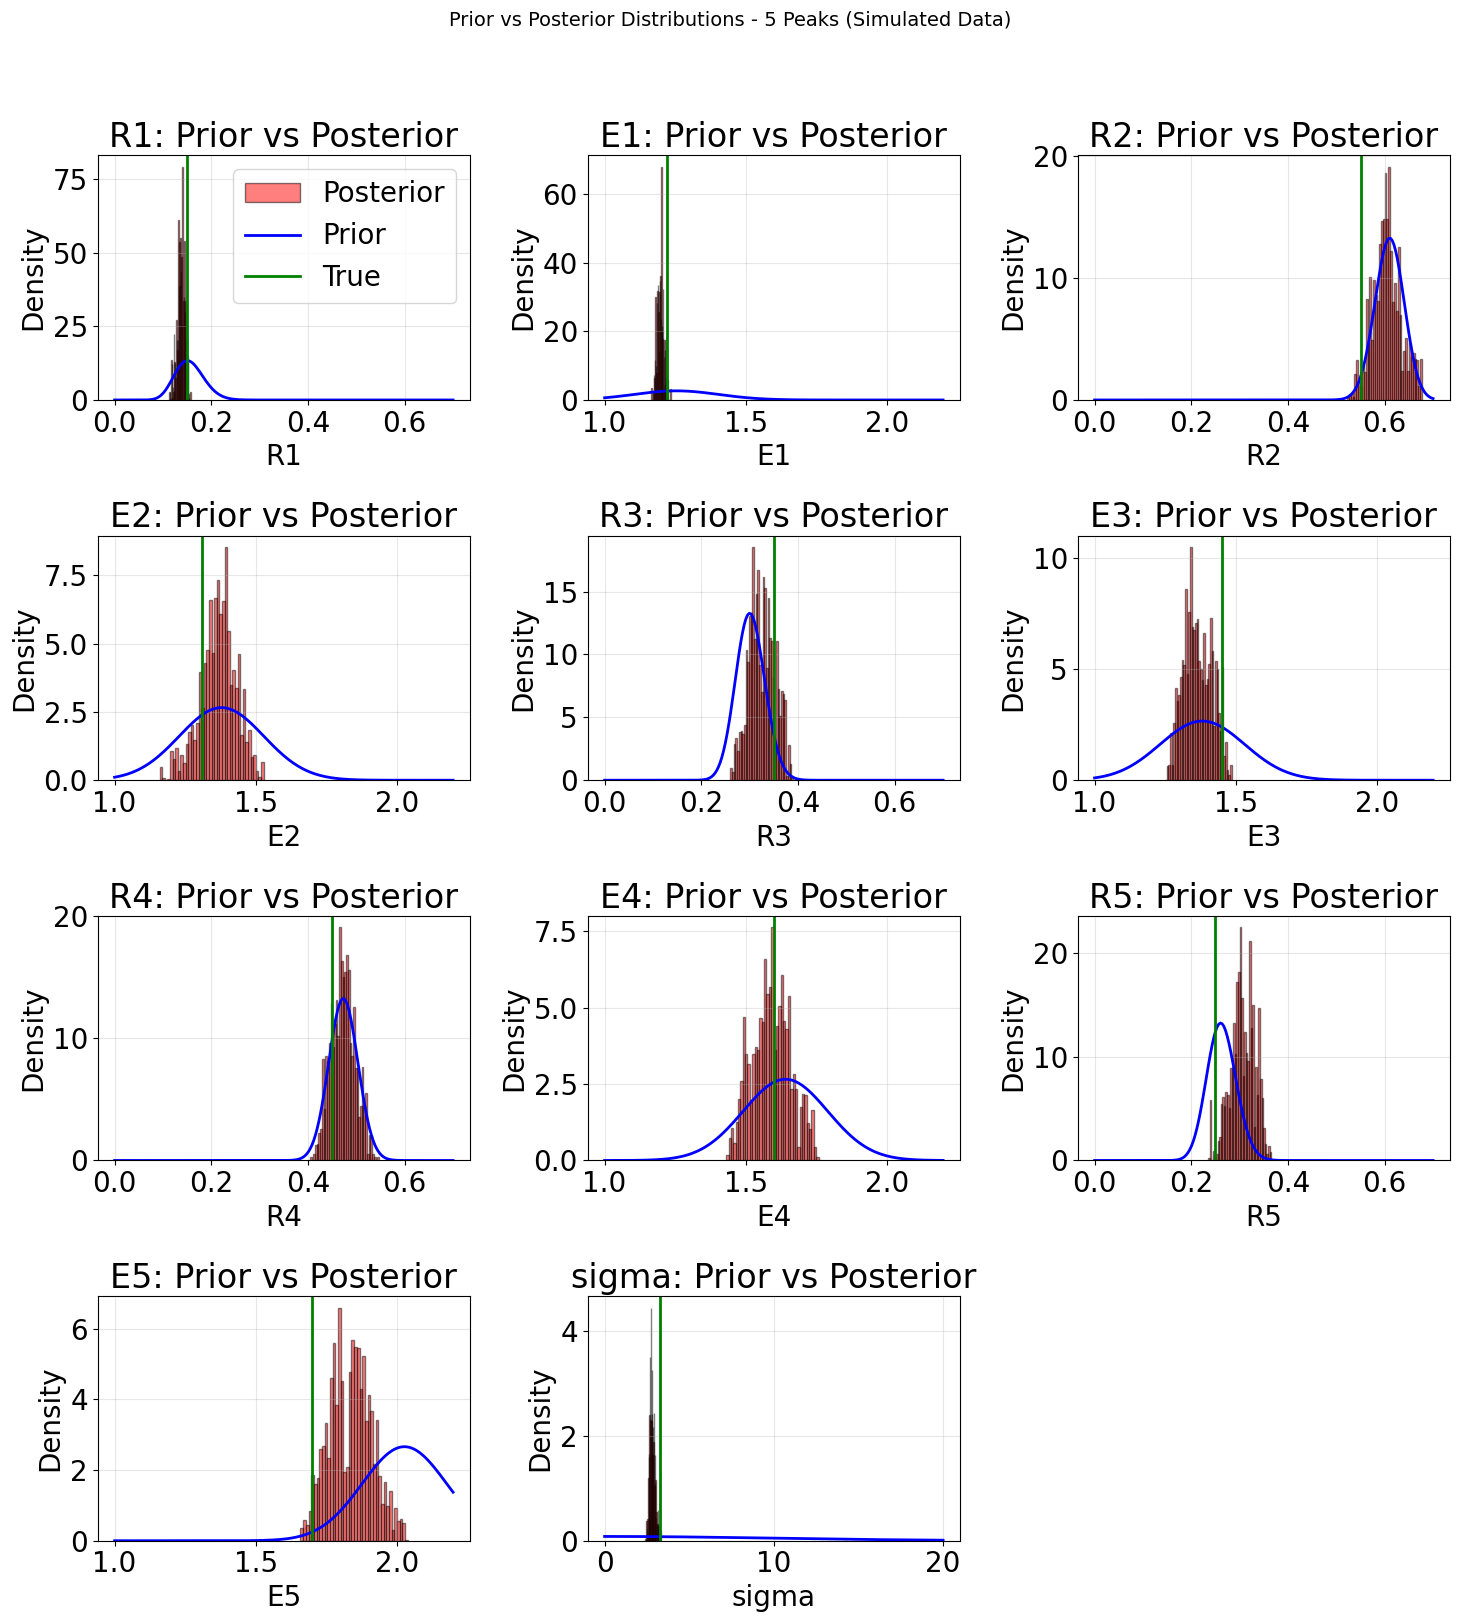


FINAL ESTIMATES - 5 PEAKS (SIMULATED DATA)
Parameter True     Estimated    95% HPD             
--------------------------------------------------
R1       0.150    0.1372   ± 0.0080    [0.1181, 0.1514]
E1       1.220    1.1971   ± 0.0117    [1.1758, 1.2204]
R2       0.550    0.6047   ± 0.0295    [0.5447, 0.6689]
E2       1.310    1.3673   ± 0.0649    [1.2182, 1.4876]
R3       0.350    0.3249   ± 0.0265    [0.2737, 0.3721]
E3       1.450    1.3662   ± 0.0504    [1.2799, 1.4570]
R4       0.450    0.4722   ± 0.0252    [0.4266, 0.5201]
E4       1.600    1.5906   ± 0.0681    [1.4702, 1.7265]
R5       0.250    0.3056   ± 0.0255    [0.2512, 0.3486]
E5       1.700    1.8361   ± 0.0755    [1.6984, 1.9887]
sigma    3.263    2.8045   ± 0.1486    [2.5419, 3.1648]

✓ Results saved to 'metropolis_5peaks_simulated_results.csv'


In [ ]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import pandas as pd
import time

# =============================================================================
# SIMULATE DATA FOR N PEAKS
# =============================================================================

np.random.seed(42)
plt.rcParams["font.size"] = 20
kB = 8.617E-5

# =============================================================================
# GENERALIZED PARAMETERS FOR N PEAKS
# =============================================================================

# Define number of peaks
n_peaks = 5  # Change this to any number

# Generate temperature range
T_min, T_max = 300, 700
n_points = 200
T = np.linspace(T_min, T_max, n_points)
x_data = T  # Temperature data

# True parameters for simulation (can modify these)
true_R = [0.15, 0.55, 0.35, 0.45, 0.25]  # Add more as needed
true_E = [1.22, 1.31, 1.45, 1.6, 1.7]  # Activation energies (eV)
true_Imax = [119.42, 19.85, 35.0, 25.0, 45.0]  # Maximum intensities
true_Tmax = [462.75, 523.38, 590.0, 550.0, 610.0]  # Peak temperatures (K)

# Ensure we have enough values for n_peaks
while len(true_R) < n_peaks:
    true_R.append(true_R[-1])
while len(true_E) < n_peaks:
    true_E.append(true_E[-1])
while len(true_Imax) < n_peaks:
    true_Imax.append(true_Imax[-1])
while len(true_Tmax) < n_peaks:
    true_Tmax.append(true_Tmax[-1])

# Fixed parameters for each peak (will be used in fitting)
FIXED_Imax = true_Imax[:n_peaks]
FIXED_Tmax = true_Tmax[:n_peaks]

# True noise level
true_sigma = 2.5  # Noise standard deviation

print("="*60)
print(f"SIMULATED DATA FOR {n_peaks}-PEAK TL MODEL")
print("="*60)
print(f"Temperature range: {T_min}-{T_max} K")
print(f"Number of data points: {n_points}")
print(f"True noise sigma: {true_sigma}")
print("\nTrue parameters used for simulation:")
for i in range(n_peaks):
    print(f"  Peak {i+1}: R={true_R[i]:.3f}, E={true_E[i]:.3f} eV, "
          f"Imax={true_Imax[i]:.1f}, Tmax={true_Tmax[i]:.1f} K")

# =============================================================================
# TL FUNCTION FOR SIMULATION
# =============================================================================

eps = 1e-10
T2 = T**2
kT_eps = kB * T + eps

def simulate_peak(R, E, Imax, Tmax):
    """Simulate a single TL peak."""
    kTmax_eps = kB * Tmax + eps
    Tmax2 = Tmax**2

    exp_arg = -E / kT_eps
    exp_val = np.exp(exp_arg)

    F = kB * T2 * exp_val * (1 - 2*kB*T/(E + eps)) / (E + eps)

    exp_arg_m = -E / kTmax_eps
    exp_val_m = np.exp(exp_arg_m)
    Fm = kB * Tmax2 * exp_val_m * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)

    a = kB * Tmax2 * (1 - 1.05 * R**1.26) + eps
    term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
    exp_term = np.exp(E / kTmax_eps)

    Z = term1 + (F * E * exp_term) / a
    Zm = term1 + (Fm * E * exp_term) / a

    Z = np.clip(Z, -500, 500)
    Zm = np.clip(Zm, -500, 500)

    argW = np.log1p(np.exp(Z))
    argWm = np.log1p(np.exp(Zm))

    denominator = argW + argW**2 + eps

    result = Imax * np.exp(-E/kT_eps * (Tmax - T)/Tmax) * (argWm + argWm**2) / denominator

    return np.where(np.isfinite(result), np.maximum(result, 0), 0)

# Generate true TL curve
y_true = np.zeros_like(T)
for i in range(n_peaks):
    y_true += simulate_peak(true_R[i], true_E[i], true_Imax[i], true_Tmax[i])

# Add noise with 10% randomness relative to signal
noise_scale = 0.10 * np.mean(y_true)  # 10% of mean signal
y_data = y_true + np.random.normal(0, noise_scale, size=len(T))
y_data = np.maximum(y_data, 0)  # Ensure non-negative

# Update true_sigma to reflect the actual noise level
true_sigma = noise_scale

print("\nData simulation complete.")
print(f"Data range: [{np.min(y_data):.2f}, {np.max(y_data):.2f}]")
print(f"Noise scale (10% of mean signal): {noise_scale:.4f}")
# Normalize (optional - can comment out if not needed)
# y_data = y_data / np.max(y_data)
# y_true = y_true / np.max(y_true)

print("\nData simulation complete.")
print(f"Data range: [{np.min(y_data):.2f}, {np.max(y_data):.2f}]")

# =============================================================================
# PRELIMINARY ESTIMATES (slightly perturbed from true values)
# =============================================================================

LS_estimates = {}
LS_uncertainties = {}

# Generate estimates with small perturbations
for i in range(n_peaks):
    LS_estimates[f'R{i+1}'] = true_R[i] * (1 + 0.1 * np.random.randn())
    LS_estimates[f'R{i+1}'] = np.clip(LS_estimates[f'R{i+1}'], 0.05, 0.95)
    LS_estimates[f'E{i+1}'] = true_E[i] * (1 + 0.05 * np.random.randn())
    LS_estimates[f'E{i+1}'] = np.clip(LS_estimates[f'E{i+1}'], 1.0, 2.2)

    LS_uncertainties[f'R{i+1}'] = 0.03
    LS_uncertainties[f'E{i+1}'] = 0.05

LS_estimates['sigma'] = true_sigma * 1.5
LS_uncertainties['sigma'] = 0.5

print("\nPreliminary estimates (used for prior means):")
for i in range(n_peaks):
    print(f"  R{i+1}: {LS_estimates[f'R{i+1}']:.3f} ± {LS_uncertainties[f'R{i+1}']:.3f}")
    print(f"  E{i+1}: {LS_estimates[f'E{i+1}']:.3f} ± {LS_uncertainties[f'E{i+1}']:.3f} eV")
print(f"  sigma: {LS_estimates['sigma']:.3f} ± {LS_uncertainties['sigma']:.3f}")

# =============================================================================
# VECTORIZED TL FUNCTION FOR N PEAKS (NUMPY ONLY)
# =============================================================================

# Pre-compute constants
T_data = x_data
T2_data = T_data**2
eps = 1e-10

# Pre-compute peak-specific constants
peak_constants = []
for i in range(n_peaks):
    peak_constants.append({
        'Imax': FIXED_Imax[i],
        'Tmax': FIXED_Tmax[i],
        'Tmax2': FIXED_Tmax[i]**2,
        'kTmax_eps': kB * FIXED_Tmax[i] + eps
    })

# Pre-compute temperature-dependent values
kT_eps_data = kB * T_data + eps

def tl_peak_numpy(R, E, peak_idx):
    """
    Calculate TL for a single peak.
    """
    const = peak_constants[peak_idx]
    Imax = const['Imax']
    Tmax = const['Tmax']
    Tmax2 = const['Tmax2']
    kTmax_eps = const['kTmax_eps']

    exp_arg = -E / kT_eps_data
    exp_val = np.exp(exp_arg)

    F = kB * T2_data * exp_val * (1 - 2*kB*T_data/(E + eps)) / (E + eps)

    exp_arg_m = -E / kTmax_eps
    exp_val_m = np.exp(exp_arg_m)
    Fm = kB * Tmax2 * exp_val_m * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)

    a = kB * Tmax2 * (1 - 1.05 * R**1.26) + eps
    term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
    exp_term = np.exp(E / kTmax_eps)

    Z = term1 + (F * E * exp_term) / a
    Zm = term1 + (Fm * E * exp_term) / a

    Z = np.clip(Z, -500, 500)
    Zm = np.clip(Zm, -500, 500)

    argW = np.log1p(np.exp(Z))
    argWm = np.log1p(np.exp(Zm))

    denominator = argW + argW**2 + eps

    result = Imax * np.exp(-E/kT_eps_data * (Tmax - T_data)/Tmax) * (argWm + argWm**2) / denominator

    return np.where(np.isfinite(result), np.maximum(result, 0), 0)

def tl_curve_numpy(*params):
    """
    Calculate total TL for n peaks.
    params: R1, E1, R2, E2, ..., Rn, En
    """
    total = np.zeros_like(T_data)
    for i in range(n_peaks):
        R = params[2*i]
        E = params[2*i + 1]
        total += tl_peak_numpy(R, E, i)
    return total

def tl_curve_numpy_batch(params_batch):
    """
    Vectorized TL calculation for multiple parameter sets.
    params_batch: array of shape (n_samples, 2*n_peaks + 1) [R1, E1, R2, E2, ..., Rn, En, sigma]
    Returns: array of shape (n_samples, n_temp)
    """
    if params_batch.ndim == 1:
        params_batch = params_batch.reshape(1, -1)

    n_samples = params_batch.shape[0]
    n_params_per_peak = 2
    result = np.zeros((n_samples, len(T_data)))

    for i in range(n_samples):
        # Extract all R and E values for this sample
        peak_params = params_batch[i, :2*n_peaks]
        result[i] = tl_curve_numpy(*peak_params)

    return result

# =============================================================================
# PRIOR DISTRIBUTIONS FOR N PEAKS
# =============================================================================

def beta_params(mu, sigma):
    var = sigma**2
    alpha = mu * (mu * (1 - mu) / var - 1)
    beta = (1 - mu) * (mu * (1 - mu) / var - 1)
    return max(alpha, 1.5), max(beta, 1.5)

# Generate Beta parameters for each R
alpha_R = {}
beta_R = {}
print(f"\nBeta priors:")
for i in range(n_peaks):
    alpha_R[i], beta_R[i] = beta_params(LS_estimates[f'R{i+1}'], LS_uncertainties[f'R{i+1}'])
    print(f"  R{i+1}: alpha={alpha_R[i]:.2f}, beta={beta_R[i]:.2f}")

# Define bounds for each parameter
param_names = []
lower_bounds = []
upper_bounds = []
for i in range(n_peaks):
    param_names.append(f'R{i+1}')
    param_names.append(f'E{i+1}')
    lower_bounds.extend([0.01, 1.0])
    upper_bounds.extend([0.99, 2.2])
param_names.append('sigma')
lower_bounds.append(0.1)
upper_bounds.append(10.0)

lower_bounds = np.array(lower_bounds)
upper_bounds = np.array(upper_bounds)
n_params = len(param_names)

def log_prior(*params):
    """Log prior probability for n peaks."""
    sigma = params[-1]

    # Check sigma bound
    if sigma <= 0:
        return -np.inf

    logp = stats.halfnorm.logpdf(sigma, scale=LS_estimates['sigma']*2)

    # Check each peak's parameters
    for i in range(n_peaks):
        R = params[2*i]
        E = params[2*i + 1]

        # Check bounds
        if R <= 0 or R >= 1 or E < 1.0 or E > 2.2:
            return -np.inf

        # Add log probabilities
        logp += stats.beta.logpdf(R, alpha_R[i], beta_R[i])
        logp += stats.norm.logpdf(E, LS_estimates[f'E{i+1}'], LS_uncertainties[f'E{i+1}']*3)

    return logp

def log_likelihood(*params):
    """Log likelihood for n peaks."""
    sigma = params[-1]
    peak_params = params[:-1]
    mu = tl_curve_numpy(*peak_params)
    return np.sum(stats.norm.logpdf(y_data, mu, sigma))

def log_posterior(*params):
    """Log posterior for n peaks."""
    lp = log_prior(*params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(*params)

# =============================================================================
# METROPOLIS SAMPLER FOR N PEAKS
# =============================================================================

def metropolis_sampler_npeaks(n_iterations=5000, n_chains=2, tune=2000):
    """
    Metropolis sampler for n-peak TL data.
    """
    # Proposal scales (tuned manually for each parameter)
    scales = np.ones(n_params) * 0.02
    # Adjust scales for specific parameters
    for i in range(n_peaks):
        scales[2*i + 1] = 0.03  # E parameters have larger scale
    scales[-1] = 0.5  # sigma scale

    # Initialize chains
    samples = np.zeros((n_chains, n_iterations + tune, n_params))
    acceptance = np.zeros((n_chains, n_iterations + tune))

    print(f"\nRunning Metropolis sampler for {n_peaks} peaks...")

    # Generate different starting points for each chain
    start_points = []
    for chain in range(n_chains):
        start = np.zeros(n_params)
        for i in range(n_peaks):
            # Perturb R and E from LS estimates
            start[2*i] = LS_estimates[f'R{i+1}'] * (1 + 0.1 * np.random.randn())
            start[2*i] = np.clip(start[2*i], 0.05, 0.95)
            start[2*i + 1] = LS_estimates[f'E{i+1}'] * (1 + 0.05 * np.random.randn())
            start[2*i + 1] = np.clip(start[2*i + 1], 1.1, 1.7)
        start[-1] = LS_estimates['sigma'] * (1 + 0.1 * np.random.randn())
        start[-1] = max(1.0, start[-1])
        start_points.append(start)

    for chain in range(n_chains):
        print(f"Evaluating chain {chain+1}")

        # Initialize
        current = start_points[chain].copy()
        current_logp = log_posterior(*current)

        for i in range(n_iterations + tune):
            # Store current
            samples[chain, i] = current

            # Randomly choose parameter to update
            param_idx = np.random.randint(n_params)

            # Propose new value
            proposal = current.copy()
            proposal[param_idx] = current[param_idx] + np.random.normal(0, scales[param_idx])

            # Check bounds
            if (proposal[param_idx] < lower_bounds[param_idx] or
                proposal[param_idx] > upper_bounds[param_idx]):
                acceptance[chain, i] = 0
                continue

            # Compute log posterior for proposal
            proposal_logp = log_posterior(*proposal)

            # Metropolis acceptance
            if np.log(np.random.random()) < proposal_logp - current_logp:
                current = proposal
                current_logp = proposal_logp
                acceptance[chain, i] = 1
            else:
                acceptance[chain, i] = 0

        chain_acc = np.mean(acceptance[chain])
        print(f"  Chain {chain+1} acceptance rate: {chain_acc:.3f}")

    return samples, acceptance, param_names

# Run sampler
samples, acceptance, param_names = metropolis_sampler_npeaks(n_iterations=5000, n_chains=2, tune=2000)

# Process samples
n_tune = 2000
samples_after_burnin = samples[:, n_tune:, :]
samples_flat = samples_after_burnin.reshape(-1, n_params)

# Calculate statistics
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)
hpd_lower = np.percentile(samples_flat, 2.5, axis=0)
hpd_upper = np.percentile(samples_flat, 97.5, axis=0)

# Print summary
print("\n" + "="*80)
print(f"PARAMETER SUMMARY - {n_peaks}-PEAK METROPOLIS SAMPLER")
print("="*80)
print(f"{'Parameter':<8} {'True':<8} {'Mean':<10} {'Std':<10} {'95% HPD Lower':<15} {'95% HPD Upper':<15}")
print("-"*70)

# Create list of true values for comparison
true_values = []
for i in range(n_peaks):
    true_values.append(true_R[i])
    true_values.append(true_E[i])
true_values.append(true_sigma)

for i, name in enumerate(param_names):
    true_val = true_values[i] if i < len(true_values) else np.nan
    print(f"{name:<8} {true_val:<8.3f} {means[i]:<10.4f} {stds[i]:<10.4f} "
          f"{hpd_lower[i]:<15.4f} {hpd_upper[i]:<15.4f}")

# =============================================================================
# CALCULATE FIT
# =============================================================================

print("\nCalculating fit statistics...")
n_fit = min(500, len(samples_flat))
indices = np.random.choice(len(samples_flat), n_fit, replace=False)
mu_samples = tl_curve_numpy_batch(samples_flat[indices])

mu_mean = np.mean(mu_samples, axis=0)
mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

# Calculate fit statistics
residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
n = len(y_data)
p = 2 * n_peaks
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
rmse = np.sqrt(np.mean(residuals**2))
fom = np.sum(np.abs(residuals)) / np.sum(mu_mean) * 100

print(f"\nR-squared: {r_squared:.4f}")
print(f"Adj R-squared: {adj_r_squared:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"FOM: {fom:.2f}%")
print(f"Average acceptance rate: {np.mean(acceptance):.3f}")

# =============================================================================
# PLOTTING - DYNAMIC SUBPLOTS
# =============================================================================

# Determine subplot layout
n_plots = n_params + 4  # Data plot + all parameters + residuals + autocorrelation
n_cols = min(3, n_plots)
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

plot_idx = 0

# Plot 1: Data vs Fit
ax = axes[plot_idx // n_cols, plot_idx % n_cols]
ax.scatter(x_data, y_data, s=5, alpha=0.5, color='blue', label='Data')
ax.plot(x_data, mu_mean, 'r-', linewidth=2, label='Fit')
ax.plot(x_data, y_true, 'g--', linewidth=1.5, label='True (noiseless)', alpha=0.7)
ax.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3, color='red')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('TL Intensity')
ax.set_title(f'(a) Data vs Fit (R² = {r_squared:.4f})')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plot_idx += 1

# Parameter posterior plots
colors = ['skyblue', 'lightgreen', 'lightcoral', 'lightyellow', 'purple']
for i in range(n_params):
    ax = axes[plot_idx // n_cols, plot_idx % n_cols]
    color = colors[i % len(colors)]

    ax.hist(samples_flat[:, i], bins=30, density=True, alpha=0.7,
            color=color, edgecolor='black')
    ax.axvline(means[i], color='blue', linewidth=2, label='Mean')
    ax.axvline(true_values[i], color='red', linewidth=2, label='True')
    ax.axvline(hpd_lower[i], color='gray', linestyle='--')
    ax.axvline(hpd_upper[i], color='gray', linestyle='--')
    ax.set_xlabel(param_names[i])
    ax.set_ylabel('Density')
    ax.set_title(f'({chr(98+plot_idx-1)}) {param_names[i]} Posterior')
    if i == 0:
        ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    plot_idx += 1

# Trace plot for first parameter
if plot_idx < n_rows * n_cols:
    ax = axes[plot_idx // n_cols, plot_idx % n_cols]
    for chain in range(min(4, samples.shape[0])):
        ax.plot(samples[chain, :, 0], alpha=0.5, linewidth=0.3, label=f'Chain {chain+1}')
    ax.axvline(n_tune, color='green', linestyle='--', label='Burn-in')
    ax.axhline(y=true_values[0], color='red', linestyle='-', linewidth=1, label='True')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(param_names[0])
    ax.set_title(f'({chr(98+plot_idx-1)}) {param_names[0]} Trace')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)
    plot_idx += 1

# Autocorrelation
if plot_idx < n_rows * n_cols:
    ax = axes[plot_idx // n_cols, plot_idx % n_cols]
    lags = 200
    for i in range(min(2, n_peaks)):
        param_idx = 2*i+1  # R parameters
        samples_param = samples_flat[:, param_idx]
        n = len(samples_param)
        samples_centered = samples_param - np.mean(samples_param)
        acf = np.correlate(samples_centered, samples_centered, mode='full') / np.var(samples_param)
        acf = acf[n-1:n-1+lags] / (n - np.arange(lags))
        ax.plot(range(lags), acf, label=param_names[param_idx], linewidth=2)
    for i in range(min(2, n_peaks)):
        param_idx = 2*i  # R parameters
        samples_param = samples_flat[:, param_idx]
        n = len(samples_param)
        samples_centered = samples_param - np.mean(samples_param)
        acf = np.correlate(samples_centered, samples_centered, mode='full') / np.var(samples_param)
        acf = acf[n-1:n-1+lags] / (n - np.arange(lags))
        ax.plot(range(lags), acf, label=param_names[param_idx], linewidth=2)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axhline(y=1.96/np.sqrt(len(samples_flat)), color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(f'({chr(98+plot_idx-1)}) Autocorrelation')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plot_idx += 1

# Residuals
if plot_idx < n_rows * n_cols:
    ax = axes[plot_idx // n_cols, plot_idx % n_cols]
    ax.scatter(x_data, residuals, s=5, alpha=0.5, color='blue')
    ax.axhline(0, color='red', linewidth=1)
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Residuals')
    ax.set_title(f'({chr(98+plot_idx-1)}) Residuals')
    ax.grid(True, alpha=0.3)
    plot_idx += 1

# Hide empty subplots
for i in range(plot_idx, n_rows * n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)

plt.suptitle(f'Bayesian Inference with Custom Metropolis Sampler ({n_peaks} Peaks - Simulated Data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# PRIOR VS POSTERIOR COMPARISON
# =============================================================================

# Determine layout for prior plots
n_prior_plots = n_params
n_prior_cols = min(3, n_prior_plots)
n_prior_rows = (n_prior_plots + n_prior_cols - 1) // n_prior_cols

fig_prior, axes_prior = plt.subplots(n_prior_rows, n_prior_cols,
                                      figsize=(5*n_prior_cols, 4*n_prior_rows))
if n_prior_rows == 1:
    axes_prior = axes_prior.reshape(1, -1)
elif n_prior_cols == 1:
    axes_prior = axes_prior.reshape(-1, 1)

for i in range(n_params):
    ax = axes_prior[i // n_prior_cols, i % n_prior_cols]

    if i < 2*n_peaks:  # R or E parameter
        peak_idx = i // 2
        is_R = (i % 2 == 0)

        if is_R:  # R parameter
            x = np.linspace(0, 0.7, 200)
            prior = stats.beta.pdf(x, alpha_R[peak_idx], beta_R[peak_idx])
        else:  # E parameter
            x = np.linspace(1.0, 2.2, 200)
            prior = stats.norm.pdf(x, LS_estimates[f'E{peak_idx+1}'],
                                   LS_uncertainties[f'E{peak_idx+1}']*3)

        ax.hist(samples_flat[:, i], bins=40, density=True, alpha=0.5,
                color='red', edgecolor='black', label='Posterior')
        ax.plot(x, prior, 'b-', linewidth=2, label='Prior')
        ax.axvline(true_values[i], color='green', linewidth=2, label='True')

    else:  # sigma parameter
        x = np.linspace(0, 20, 200)
        prior = stats.halfnorm.pdf(x, scale=LS_estimates['sigma']*2)
        ax.hist(samples_flat[:, i], bins=40, density=True, alpha=0.5,
                color='red', edgecolor='black', label='Posterior')
        ax.plot(x, prior, 'b-', linewidth=2, label='Prior')
        ax.axvline(true_values[i], color='green', linewidth=2, label='True')

    ax.set_xlabel(param_names[i])
    ax.set_ylabel('Density')
    ax.set_title(f'{param_names[i]}: Prior vs Posterior')
    if i == 0:
        ax.legend()
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for i in range(n_params, n_prior_rows * n_prior_cols):
    axes_prior[i // n_prior_cols, i % n_prior_cols].set_visible(False)

plt.suptitle(f'Prior vs Posterior Distributions - {n_peaks} Peaks (Simulated Data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print(f"FINAL ESTIMATES - {n_peaks} PEAKS (SIMULATED DATA)")
print("="*60)
print(f"{'Parameter':<8} {'True':<8} {'Estimated':<12} {'95% HPD':<20}")
print("-"*50)
for i, name in enumerate(param_names):
    true_val = true_values[i]
    print(f"{name:<8} {true_val:<8.3f} {means[i]:<8.4f} ± {stds[i]:<8.4f}  "
          f"[{hpd_lower[i]:.4f}, {hpd_upper[i]:.4f}]")

# Save results
results_df = pd.DataFrame({
    'Parameter': param_names,
    'True': true_values,
    'Mean': means,
    'Std': stds,
    'HDI_2.5%': hpd_lower,
    'HDI_97.5%': hpd_upper
})
results_df.to_csv(f'metropolis_{n_peaks}peaks_simulated_results.csv', index=False)
print(f"\n✓ Results saved to 'metropolis_{n_peaks}peaks_simulated_results.csv'")
# @
# @

**Code 4** Slice code, single peak

SLICE SAMPLING FOR SINGLE PEAK TL DECONVOLUTION

Fixed parameters: Imax=1.00, Tmax=494.61 K

RUNNING SLICE SAMPLER

Running 2 chains with 1000 iterations...
  Chain 1 completed
  Chain 2 completed

PARAMETER SUMMARY
Param  Mean     Std      HPD Lower  HPD Upper 
--------------------------------------------------
R      0.0875   0.0098   0.0687     0.1059    
E      0.9731   0.0084   0.9584     0.9905    
sigma  0.0212   0.0024   0.0168     0.0260    

R-hat: {'R': '0.9993', 'E': '0.9990', 'sigma': '0.9992'}

Calculating fit statistics...
R² = 0.9961, RMSE = 0.0204, FOM = 3.46%


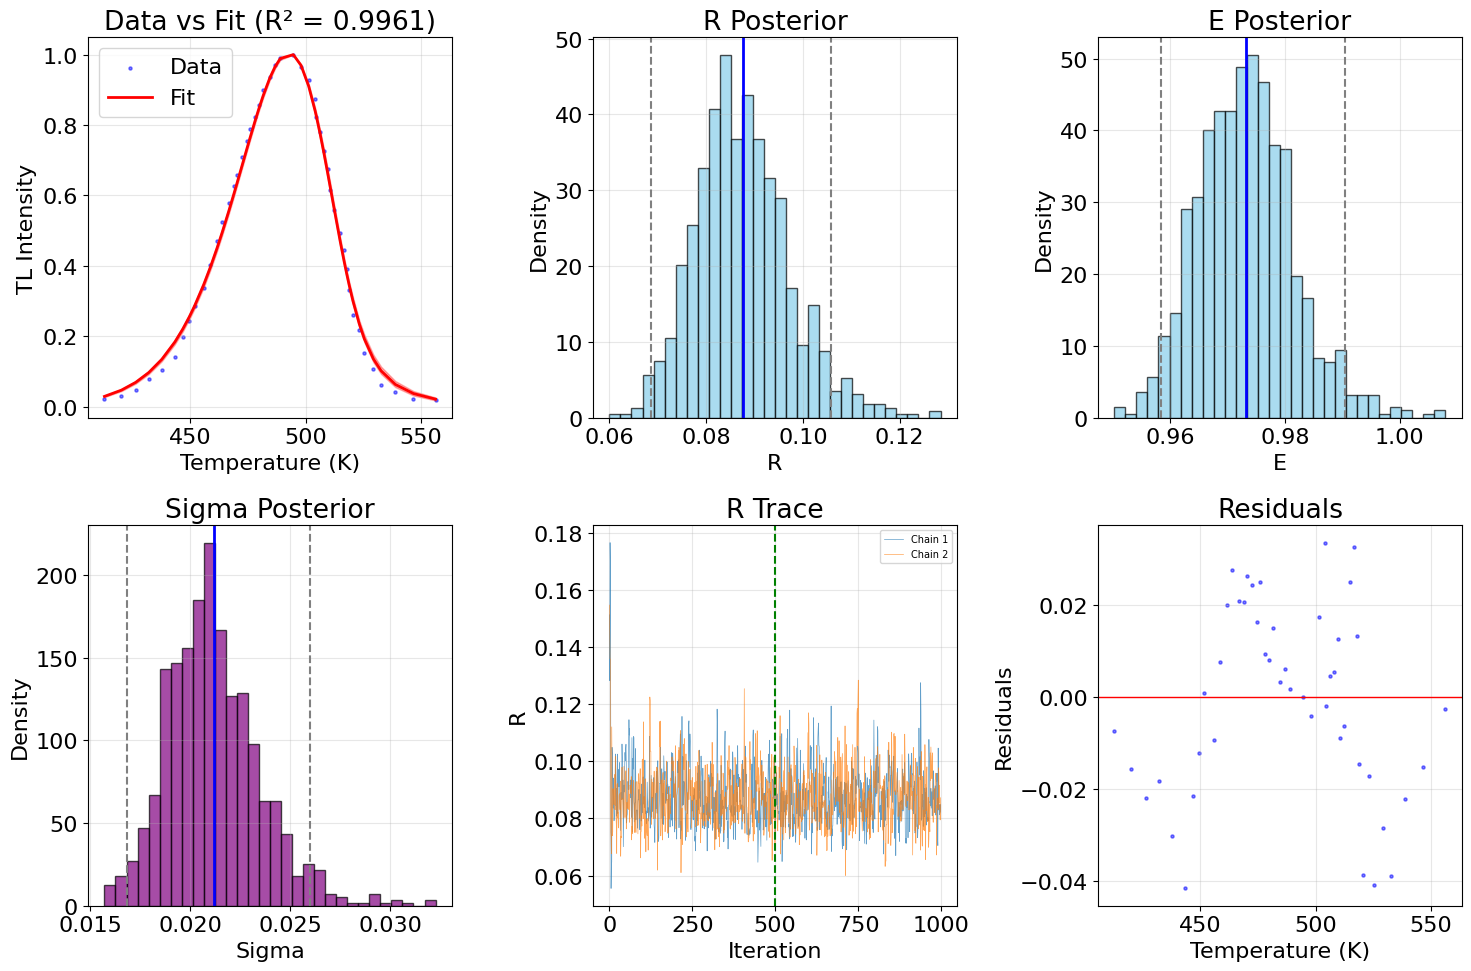


FINAL ESTIMATES
R: 0.0875 ± 0.0098  [95% HPD: 0.0687, 0.1059]
E: 0.9731 ± 0.0084  [95% HPD: 0.9584, 0.9905]
sigma: 0.0212 ± 0.0024  [95% HPD: 0.0168, 0.0260]

✓ Results saved to 'slice_results.csv'


In [ ]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import pandas as pd

plt.rcParams["font.size"] = 16
np.random.seed(142)

# =============================================================================
# DATA LOADING AND SETUP
# =============================================================================

def readData():
    """Read TL data from GitHub."""
    url = 'https://github.com/vpagonis/Python-Codes/raw/main/Ch3PagonisGitHub/aluminaTLshort.TXT'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy() + 273.15  # Convert to Kelvin
    y_data = df.iloc[:, 1].to_numpy()

    # Normalize
    y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5

# Fixed parameters
FIXED_Imax = 1.0
FIXED_Tmax = Tmax_data

# Preliminary estimates
LS_estimates = {'R': 0.15, 'E': 1.0, 'sigma': 0.01}
LS_uncertainties = {'R': 0.03, 'E': 0.05, 'sigma': 0.001}

print("="*60)
print("SLICE SAMPLING FOR SINGLE PEAK TL DECONVOLUTION")
print("="*60)
print(f"\nFixed parameters: Imax={FIXED_Imax:.2f}, Tmax={FIXED_Tmax:.2f} K")

# =============================================================================
# VECTORIZED TL GLOW CURVE FUNCTIONS
# =============================================================================

# Pre-compute constants
T = x_data
T2 = T**2
Tmax = FIXED_Tmax
Tmax2 = Tmax**2
eps = 1e-6

def tl_peak_intensity(R, E):
    """
    Vectorized TL intensity calculation.
    """
    # Common terms
    exp_arg = -E/(kB*T + eps)
    exp_val = np.exp(exp_arg)

    F_val = kB * T2 * exp_val * (1 - 2*kB*T/(E + eps)) / (E + eps)

    exp_arg_m = -E/(kB*Tmax + eps)
    exp_val_m = np.exp(exp_arg_m)
    Fm = kB * Tmax2 * exp_val_m * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)

    a = kB * Tmax2 * (1 - 1.05 * R**1.26) + eps
    term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
    exp_term = np.exp(E/(kB*Tmax + eps))

    Z = term1 + (F_val * E * exp_term) / a
    Zm = term1 + (Fm * E * exp_term) / a

    Z = np.clip(Z, -500, 500)
    Zm = np.clip(Zm, -500, 500)

    argW = np.log1p(np.exp(Z))
    argWm = np.log1p(np.exp(Zm))

    denominator = argW + argW**2 + eps
    result = FIXED_Imax * np.exp(-E/(kB*T + eps) * (Tmax - T)/Tmax) * (argWm + argWm**2) / denominator

    return np.where(np.isfinite(result), np.maximum(result, 0), 0)

def tl_glow_curve(params):
    """Wrapper for single parameter set."""
    return tl_peak_intensity(params[0], params[1])

# =============================================================================
# PRIOR DISTRIBUTIONS
# =============================================================================

# Beta parameters for R
mu_R, sigma_R = LS_estimates['R'], LS_uncertainties['R']
var_R = sigma_R**2
alpha_R = max(mu_R * (mu_R * (1 - mu_R) / var_R - 1), 1.01)
beta_R = max((1 - mu_R) * (mu_R * (1 - mu_R) / var_R - 1), 1.01)

def log_prior(params):
    """Vectorized joint log prior."""
    R, E, sigma = params

    # Check bounds
    if R <= 0 or R >= 1 or E < 0.5 or E > 1.3 or sigma <= 0:
        return -np.inf

    log_prior_R = stats.beta.logpdf(R, alpha_R, beta_R)
    log_prior_E = stats.norm.logpdf(E, LS_estimates['E'], LS_uncertainties['E']*3)
    log_prior_sigma = stats.halfnorm.logpdf(sigma, scale=LS_estimates['sigma']*2)

    return log_prior_R + log_prior_E + log_prior_sigma

def log_likelihood(params):
    """Log likelihood."""
    mu = tl_peak_intensity(params[0], params[1])
    return np.sum(stats.norm.logpdf(y_data, mu, params[2]))

def log_posterior(params):
    """Log posterior."""
    lp = log_prior(params)
    return -np.inf if not np.isfinite(lp) else lp + log_likelihood(params)

# =============================================================================
# SIMPLIFIED SLICE SAMPLING
# =============================================================================

def slice_sample_1d(current, log_target, idx, bounds, w=0.1, m=100):
    """
    Simplified univariate slice sampling.
    """
    lower, upper = bounds

    def target_at_x(x):
        params = current.copy()
        params[idx] = x
        return log_target(params)

    # Slice level
    log_y = target_at_x(current[idx]) - np.random.exponential(1)

    # Stepping out
    L = current[idx] - w * np.random.random()
    R = L + w

    # Expand interval
    for _ in range(m):
        if L <= lower or target_at_x(L) <= log_y:
            break
        L -= w
    for _ in range(m):
        if R >= upper or target_at_x(R) <= log_y:
            break
        R += w

    L = max(L, lower)
    R = min(R, upper)

    # Sample with shrinkage
    while True:
        x_new = L + np.random.random() * (R - L)
        if target_at_x(x_new) > log_y:
            return x_new
        if x_new < current[idx]:
            L = x_new
        else:
            R = x_new

def slice_sampler(initial, n_iterations=1000, n_chains=2, w=[0.05, 0.1, 1.0]):
    """
    Simplified slice sampler.
    """
    param_names = ['R', 'E', 'sigma']
    bounds = [(0, 1), (0.8, 1.1), (0, np.inf)]

    samples = np.zeros((n_chains, n_iterations, 3))

    print(f"\nRunning {n_chains} chains with {n_iterations} iterations...")

    for chain in range(n_chains):
        # Initialize
        current = np.array([
            np.clip(initial['R'] + np.random.normal(0, 0.01), 0.01, 0.99),
            np.clip(initial['E'] + np.random.normal(0, 0.02), 0.8, 1.1),
            max(0.1, initial['sigma'] + np.random.normal(0, 0.5))
        ])

        for i in range(n_iterations):
            samples[chain, i] = current

            # Update each parameter
            for j in range(3):
                current[j] = slice_sample_1d(current, log_posterior, j, bounds[j], w[j])

        print(f"  Chain {chain+1} completed")

    return samples, param_names

# =============================================================================
# FAST DIAGNOSTICS
# =============================================================================

def gelman_rubin(samples):
    """Fast Gelman-Rubin."""
    n_chains, n_samples, n_params = samples.shape

    chain_means = np.mean(samples, axis=1)
    chain_vars = np.var(samples, axis=1, ddof=1)

    W = np.mean(chain_vars, axis=0)
    B = n_samples * np.var(chain_means, axis=0, ddof=1)

    var_plus = (n_samples - 1) / n_samples * W + B / n_samples
    return np.sqrt(var_plus / W)

def effective_sample_size(x):
    """Fast ESS."""
    n = len(x)
    x_centered = x - np.mean(x)
    acf = np.correlate(x_centered, x_centered, mode='full') / np.var(x)
    acf = acf[n-1:n+100] / (n - np.arange(min(101, n)))

    cutoff = np.where(acf[1:] <= 0)[0]
    cutoff = cutoff[0] + 1 if len(cutoff) > 0 else len(acf)

    return n / (1 + 2 * np.sum(acf[1:cutoff]))

def hpd_interval(x, prob=0.95):
    """Fast HPD."""
    n = len(x)
    x_sort = np.sort(x)
    m = int(round(n * prob))
    intervals = x_sort[m-1:] - x_sort[:n-m+1]
    start = np.argmin(intervals)
    return np.array([x_sort[start], x_sort[start + m - 1]])

# =============================================================================
# RUN SAMPLER
# =============================================================================

n_iterations, n_burnin, n_chains = 1000, 500, 2

print("\n" + "="*60)
print("RUNNING SLICE SAMPLER")
print("="*60)

samples, param_names = slice_sampler(LS_estimates, n_iterations, n_chains)

# Process samples
samples_after_burnin = samples[:, n_burnin:, :]
samples_flat = samples_after_burnin.reshape(-1, 3)

# Statistics
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)
hpd_lower = np.array([hpd_interval(samples_flat[:, i])[0] for i in range(3)])
hpd_upper = np.array([hpd_interval(samples_flat[:, i])[1] for i in range(3)])

# Print summary
print("\n" + "="*80)
print("PARAMETER SUMMARY")
print("="*80)
print(f"{'Param':<6} {'Mean':<8} {'Std':<8} {'HPD Lower':<10} {'HPD Upper':<10}")
print("-"*50)
for i, name in enumerate(param_names):
    print(f"{name:<6} {means[i]:<8.4f} {stds[i]:<8.4f} {hpd_lower[i]:<10.4f} {hpd_upper[i]:<10.4f}")

# R-hat
r_hat = gelman_rubin(samples_after_burnin)
print("\nR-hat:", {name: f"{r_hat[i]:.4f}" for i, name in enumerate(param_names)})

# =============================================================================
# FIT STATISTICS (VECTORIZED)
# =============================================================================

print("\nCalculating fit statistics...")
n_fit = min(500, len(samples_flat))
idx = np.random.choice(len(samples_flat), n_fit, replace=False)

# Vectorized fit calculation
mu_samples = np.array([tl_peak_intensity(samples_flat[i, 0], samples_flat[i, 1])
                       for i in idx])

mu_mean = np.mean(mu_samples, axis=0)
mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

# Statistics
residuals = y_data - mu_mean
ss_res, ss_tot = np.sum(residuals**2), np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - ss_res/ss_tot
rmse = np.sqrt(np.mean(residuals**2))
fom = np.sum(np.abs(residuals)) / np.sum(mu_mean) * 100

print(f"R² = {r_squared:.4f}, RMSE = {rmse:.4f}, FOM = {fom:.2f}%")

# =============================================================================
# SIMPLIFIED PLOTTING
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Data vs Fit
ax = axes[0, 0]
ax.scatter(x_data, y_data, s=5, alpha=0.5, color='blue', label='Data')
ax.plot(x_data, mu_mean, 'r-', linewidth=2, label='Fit')
ax.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3, color='red')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('TL Intensity')
ax.set_title(f'Data vs Fit (R² = {r_squared:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Posterior distributions
for i, (ax, name, color) in enumerate(zip(axes[0, 1:], ['R', 'E'], ['skyblue', 'skyblue'])):
    ax.hist(samples_flat[:, i], bins=30, density=True, alpha=0.7, color=color, edgecolor='black')
    ax.axvline(means[i], color='blue', linewidth=2)
    ax.axvline(hpd_lower[i], color='gray', linestyle='--')
    ax.axvline(hpd_upper[i], color='gray', linestyle='--')
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.set_title(f'{name} Posterior')
    ax.grid(True, alpha=0.3)

# Sigma posterior
ax = axes[1, 0]
ax.hist(samples_flat[:, 2], bins=30, density=True, alpha=0.7, color='purple', edgecolor='black')
ax.axvline(means[2], color='blue', linewidth=2)
ax.axvline(hpd_lower[2], color='gray', linestyle='--')
ax.axvline(hpd_upper[2], color='gray', linestyle='--')
ax.set_xlabel('Sigma')
ax.set_ylabel('Density')
ax.set_title('Sigma Posterior')
ax.grid(True, alpha=0.3)

# Trace plots
ax = axes[1, 1]
for chain in range(n_chains):
    ax.plot(samples[chain, :, 0], alpha=0.7, linewidth=0.5, label=f'Chain {chain+1}')
ax.axvline(n_burnin, color='green', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('R')
ax.set_title('R Trace')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Residuals
ax = axes[1, 2]
ax.scatter(x_data, residuals, s=5, alpha=0.5, color='blue')
ax.axhline(0, color='red', linewidth=1)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Residuals')
ax.set_title('Residuals')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "="*60)
print("FINAL ESTIMATES")
print("="*60)
for i, name in enumerate(param_names):
    print(f"{name}: {means[i]:.4f} ± {stds[i]:.4f}  [95% HPD: {hpd_lower[i]:.4f}, {hpd_upper[i]:.4f}]")

# Save results
pd.DataFrame({
    'Parameter': param_names, 'Mean': means, 'Std': stds,
    'HDI_2.5%': hpd_lower, 'HDI_97.5%': hpd_upper, 'R_hat': r_hat
}).to_csv('slice_results.csv', index=False)
print("\n✓ Results saved to 'slice_results.csv'")
# @

**Code 5** Slice code, double peak

OPTIMIZED SLICE SAMPLING FOR TL DECONVOLUTION

Fixed: Imax1=119.4, Tmax1=462.8K, Imax2=19.9, Tmax2=523.4K

RUNNING OPTIMIZED SLICE SAMPLER

Running 2 chains with 1000 iterations...
  Chain 1 completed in 28.8s
  Chain 2 completed in 58.1s

Total time: 58.08 seconds

PARAMETER SUMMARY
Param  Mean     Std      HPD Lower  HPD Upper 
--------------------------------------------------
R1     0.1610   0.0516   0.0618     0.2574    
E1     1.2571   0.0657   1.1344     1.3844    
R2     0.5350   0.0378   0.4618     0.6093    
E2     1.5526   0.1582   1.2487     1.8514    
sigma  6.5353   0.7456   5.2551     8.0931    

R-hat: {'R1': '1.0337', 'E1': '1.0285', 'R2': '0.9993', 'E2': '0.9992', 'sigma': '0.9995'}

Calculating fit statistics...
R² = 0.9669


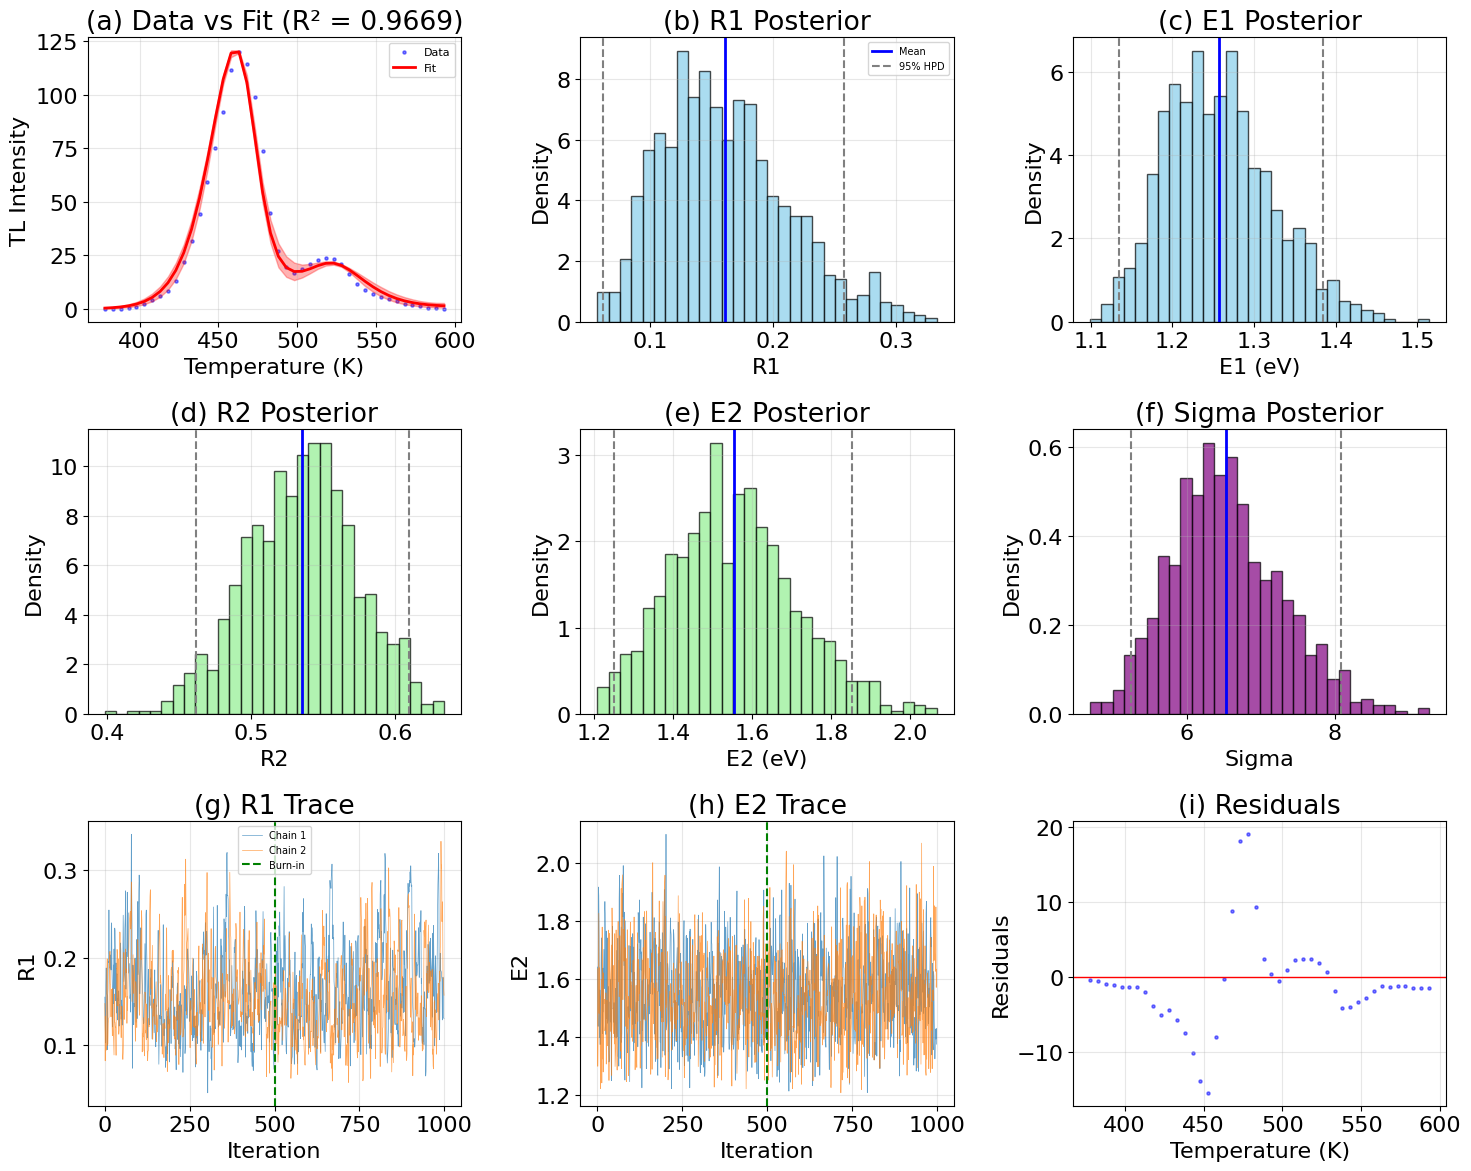

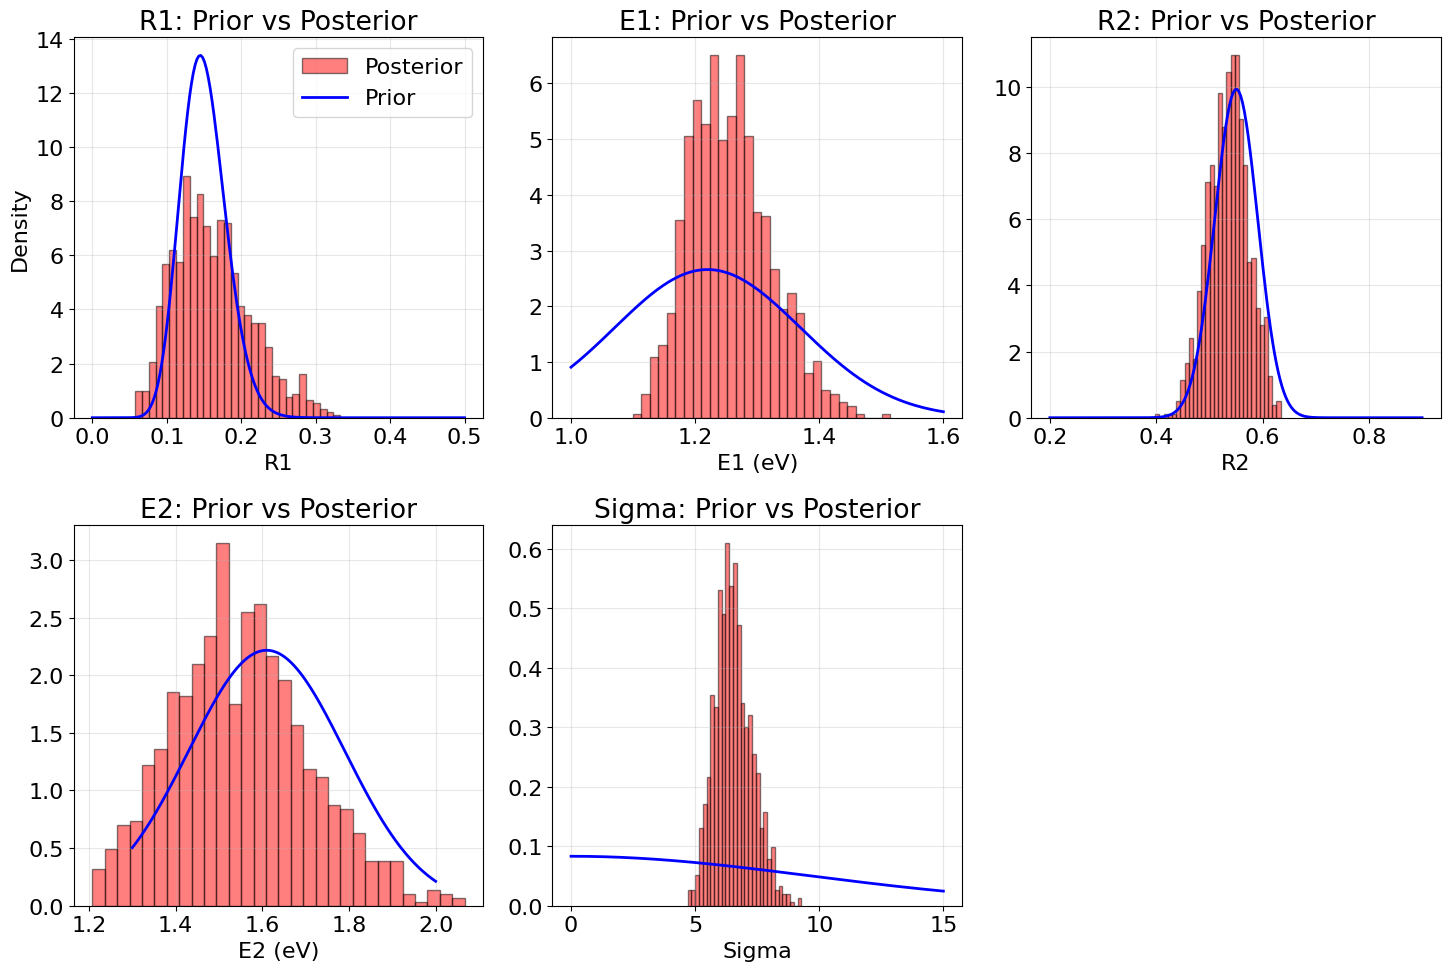


FINAL ESTIMATES
R1: 0.1610 ± 0.0516  [95% HPD: 0.0618, 0.2574]
E1: 1.2571 ± 0.0657  [95% HPD: 1.1344, 1.3844]
R2: 0.5350 ± 0.0378  [95% HPD: 0.4618, 0.6093]
E2: 1.5526 ± 0.1582  [95% HPD: 1.2487, 1.8514]
sigma: 6.5353 ± 0.7456  [95% HPD: 5.2551, 8.0931]

✓ Results saved to 'slice_results_functional.csv'


In [ ]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import pandas as pd
import time

plt.rcParams["font.size"] = 16
np.random.seed(42)

def readData():
    """Read TL data from GitHub."""
    url = 'https://raw.githubusercontent.com/vpagonis/Python-Codes/refs/heads/main/Ch3PagonisGitHub/lbodata.txt'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy()   # temperature in Kelvin
    y_data = df.iloc[:, 1].to_numpy()

    # Normalize
    # y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5

# Fixed parameters
FIXED_Imax1, FIXED_Tmax1 = 119.42, 462.75
FIXED_Imax2, FIXED_Tmax2 = 19.85, 523.38

# Preliminary estimates
LS_estimates = {'R1': 0.15, 'E1': 1.22, 'R2': 0.55, 'E2': 1.61, 'sigma': 4.8}
LS_uncertainties = {'R1': 0.03, 'E1': 0.05, 'R2': 0.04, 'E2': 0.06, 'sigma': 0.5}

print("="*60)
print("OPTIMIZED SLICE SAMPLING FOR TL DECONVOLUTION")
print("="*60)
print(f"\nFixed: Imax1={FIXED_Imax1:.1f}, Tmax1={FIXED_Tmax1:.1f}K, Imax2={FIXED_Imax2:.1f}, Tmax2={FIXED_Tmax2:.1f}K")

# =============================================================================
# VECTORIZED TL FUNCTIONS - PRE-COMPUTED CONSTANTS
# =============================================================================

# Pre-compute constants
T = x_data
T2 = T**2
eps = 1e-6
Tmax1, Tmax2 = FIXED_Tmax1, FIXED_Tmax2
Tmax1_2, Tmax2_2 = Tmax1**2, Tmax2**2

# Cache frequently used values
kT = kB * T
kT_eps = kT + eps
kTmax1_eps = kB*Tmax1 + eps
kTmax2_eps = kB*Tmax2 + eps

def tl_glow_curve_fast(params):
    """Ultra-fast TL calculation."""
    R1, E1, R2, E2, sigma = params

    # Peak 1 calculations
    exp_arg1 = -E1/kT_eps
    exp_val1 = np.exp(exp_arg1)

    F1 = kB * T2 * exp_val1 * (1 - 2*kT/(E1 + eps)) / (E1 + eps)

    exp_arg_m1 = -E1/kTmax1_eps
    exp_val_m1 = np.exp(exp_arg_m1)
    Fm1 = kB * Tmax1_2 * exp_val_m1 * (1 - 2*kB*Tmax1/(E1 + eps)) / (E1 + eps)

    a1 = kB * Tmax1_2 * (1 - 1.05 * R1**1.26) + eps
    term1_1 = R1/(1-R1 + eps) - np.log((1-R1)/(R1 + eps) + eps)
    exp_term1 = np.exp(E1/kTmax1_eps)

    Z1 = term1_1 + (F1 * E1 * exp_term1) / a1
    Zm1 = term1_1 + (Fm1 * E1 * exp_term1) / a1

    Z1 = np.clip(Z1, -500, 500)
    Zm1 = np.clip(Zm1, -500, 500)

    argW1 = np.log1p(np.exp(Z1))
    argWm1 = np.log1p(np.exp(Zm1))

    denom1 = argW1 + argW1**2 + eps
    peak1 = FIXED_Imax1 * np.exp(-E1/kT_eps * (Tmax1 - T)/Tmax1) * (argWm1 + argWm1**2) / denom1

    # Peak 2 calculations
    exp_arg2 = -E2/kT_eps
    exp_val2 = np.exp(exp_arg2)

    F2 = kB * T2 * exp_val2 * (1 - 2*kT/(E2 + eps)) / (E2 + eps)

    exp_arg_m2 = -E2/kTmax2_eps
    exp_val_m2 = np.exp(exp_arg_m2)
    Fm2 = kB * Tmax2_2 * exp_val_m2 * (1 - 2*kB*Tmax2/(E2 + eps)) / (E2 + eps)

    a2 = kB * Tmax2_2 * (1 - 1.05 * R2**1.26) + eps
    term1_2 = R2/(1-R2 + eps) - np.log((1-R2)/(R2 + eps) + eps)
    exp_term2 = np.exp(E2/kTmax2_eps)

    Z2 = term1_2 + (F2 * E2 * exp_term2) / a2
    Zm2 = term1_2 + (Fm2 * E2 * exp_term2) / a2

    Z2 = np.clip(Z2, -500, 500)
    Zm2 = np.clip(Zm2, -500, 500)

    argW2 = np.log1p(np.exp(Z2))
    argWm2 = np.log1p(np.exp(Zm2))

    denom2 = argW2 + argW2**2 + eps
    peak2 = FIXED_Imax2 * np.exp(-E2/kT_eps * (Tmax2 - T)/Tmax2) * (argWm2 + argWm2**2) / denom2

    total = np.where(np.isfinite(peak1), np.maximum(peak1, 0), 0) + \
            np.where(np.isfinite(peak2), np.maximum(peak2, 0), 0)

    return total

# =============================================================================
# PRIOR DISTRIBUTIONS
# =============================================================================

def beta_params(mu, sigma):
    var = sigma**2
    alpha = mu * (mu * (1 - mu) / var - 1)
    beta = (1 - mu) * (mu * (1 - mu) / var - 1)
    return max(alpha, 1.01), max(beta, 1.01)

alpha_R1, beta_R1 = beta_params(LS_estimates['R1'], LS_uncertainties['R1'])
alpha_R2, beta_R2 = beta_params(LS_estimates['R2'], LS_uncertainties['R2'])

# Pre-compute prior constants
prior_E1_mean, prior_E1_scale = LS_estimates['E1'], LS_uncertainties['E1']*3
prior_E2_mean, prior_E2_scale = LS_estimates['E2'], LS_uncertainties['E2']*3
prior_sigma_scale = LS_estimates['sigma']*2

# Bounds
bounds = np.array([[0, 1], [1.0, 1.8], [0, 1], [1.2, 2.2], [0, np.inf]])
w_values = [0.05, 0.1, 0.05, 0.1, 1.0]  # Step sizes for each parameter
m_steps = 50  # Maximum steps for stepping out

def log_posterior_fast(params):
    """Ultra-fast log posterior."""
    R1, E1, R2, E2, sigma = params

    # Fast bound check
    if not (0 < R1 < 1 and 0 < R2 < 1 and
            1.0 <= E1 <= 1.8 and 1.2 <= E2 <= 2.2 and sigma > 0):
        return -1e300

    # Log prior
    logp = (stats.beta.logpdf(R1, alpha_R1, beta_R1) +
            stats.norm.logpdf(E1, prior_E1_mean, prior_E1_scale) +
            stats.beta.logpdf(R2, alpha_R2, beta_R2) +
            stats.norm.logpdf(E2, prior_E2_mean, prior_E2_scale) +
            stats.halfnorm.logpdf(sigma, scale=prior_sigma_scale))

    if not np.isfinite(logp):
        return -1e300

    # Log likelihood
    mu = tl_glow_curve_fast(params)
    log_lik = -0.5 * len(y_data) * np.log(2 * np.pi) - len(y_data) * np.log(sigma) - \
              0.5 * np.sum(((y_data - mu) / sigma)**2)

    return logp + log_lik

# =============================================================================
# FUNCTION-BASED SLICE SAMPLING (NO CLASSES)
# =============================================================================

# Global cache for posterior calculations
_posterior_cache = {}
_cache_size_limit = 1000

def cached_log_posterior(params):
    """Cached version of log_posterior_fast."""
    global _posterior_cache
    key = tuple(np.round(params, 4))
    if key not in _posterior_cache:
        _posterior_cache[key] = log_posterior_fast(params)
        if len(_posterior_cache) > _cache_size_limit:
            # Remove a random item
            _posterior_cache.pop(next(iter(_posterior_cache)))
    return _posterior_cache[key]

def slice_sample_1d(current, idx, bounds, w, m):
    """
    Univariate slice sampling using the "stepping out" procedure.
    """
    lower, upper = bounds[idx]
    w_param = w[idx]

    def target_at_x(x):
        params = current.copy()
        params[idx] = x
        return cached_log_posterior(params)

    # Current value and slice level
    x0 = current[idx]
    log_y = target_at_x(x0) - np.random.exponential(1)

    # Stepping out - with early stopping
    L = x0 - w_param * np.random.random()
    R = L + w_param

    # Expand left
    steps = 0
    while steps < m and L > lower and target_at_x(L) > log_y:
        L -= w_param
        steps += 1

    # Expand right
    steps = 0
    while steps < m and R < upper and target_at_x(R) > log_y:
        R += w_param
        steps += 1

    L, R = max(L, lower), min(R, upper)

    # Sample with shrinkage - limit iterations
    for _ in range(100):  # Max attempts
        x_new = L + np.random.random() * (R - L)
        if target_at_x(x_new) > log_y:
            return x_new
        if x_new < x0:
            L = x_new
        else:
            R = x_new

    return x0  # Fallback

def slice_sampler_functional(initial, n_iter=2000, n_chains=2):
    """
    Functional slice sampler (no classes).
    """
    param_names = ['R1', 'E1', 'R2', 'E2', 'sigma']
    init_array = np.array([initial[name] for name in param_names])
    n_params = len(param_names)

    samples = np.zeros((n_chains, n_iter, n_params))

    print(f"\nRunning {n_chains} chains with {n_iter} iterations...")
    start_time = time.time()

    for chain in range(n_chains):
        # Initialize
        current = init_array.copy()
        current += np.random.normal(0, [0.01, 0.02, 0.01, 0.02, 0.5])
        current = np.clip(current, bounds[:, 0], bounds[:, 1])
        current[4] = max(0.1, current[4])

        # Warm up cache with initial value
        cached_log_posterior(current)

        for i in range(n_iter):
            samples[chain, i] = current

            # Update each parameter
            for j in range(n_params):
                current[j] = slice_sample_1d(current, j, bounds, w_values, m_steps)

        print(f"  Chain {chain+1} completed in {time.time()-start_time:.1f}s")

    print(f"\nTotal time: {time.time()-start_time:.2f} seconds")

    # Clear cache to free memory
    global _posterior_cache
    _posterior_cache.clear()

    return samples, param_names

# =============================================================================
# FAST DIAGNOSTICS
# =============================================================================

def gelman_rubin_fast(samples):
    """Vectorized Gelman-Rubin."""
    n_chains, n_samples, n_params = samples.shape
    chain_means = np.mean(samples, axis=1)
    chain_vars = np.var(samples, axis=1, ddof=1)
    W = np.mean(chain_vars, axis=0)
    B = n_samples * np.var(chain_means, axis=0, ddof=1)
    return np.sqrt(((n_samples-1)/n_samples * W + B/n_samples) / W)

def hpd_interval_fast(x, prob=0.95):
    """Vectorized HPD."""
    n = len(x)
    x_sort = np.sort(x)
    m = int(round(n * prob))
    intervals = x_sort[m-1:] - x_sort[:n-m+1]
    start = np.argmin(intervals)
    return np.array([x_sort[start], x_sort[start + m - 1]])

# =============================================================================
# RUN SAMPLER
# =============================================================================

n_iter, n_burnin, n_chains = 1000, 500, 2

print("\n" + "="*60)
print("RUNNING OPTIMIZED SLICE SAMPLER")
print("="*60)

samples, param_names = slice_sampler_functional(LS_estimates, n_iter, n_chains)

# Process samples
samples_after_burnin = samples[:, n_burnin:, :]
samples_flat = samples_after_burnin.reshape(-1, 5)

# Statistics
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)
hpd_lower = np.array([hpd_interval_fast(samples_flat[:, i])[0] for i in range(5)])
hpd_upper = np.array([hpd_interval_fast(samples_flat[:, i])[1] for i in range(5)])

# Print summary
print("\n" + "="*80)
print("PARAMETER SUMMARY")
print("="*80)
print(f"{'Param':<6} {'Mean':<8} {'Std':<8} {'HPD Lower':<10} {'HPD Upper':<10}")
print("-"*50)
for i, name in enumerate(param_names):
    print(f"{name:<6} {means[i]:<8.4f} {stds[i]:<8.4f} {hpd_lower[i]:<10.4f} {hpd_upper[i]:<10.4f}")

# R-hat
r_hat = gelman_rubin_fast(samples_after_burnin)
print("\nR-hat:", {name: f"{r_hat[i]:.4f}" for i, name in enumerate(param_names)})

# =============================================================================
# FIT STATISTICS
# =============================================================================

print("\nCalculating fit statistics...")
n_fit = min(200, len(samples_flat))
idx = np.random.choice(len(samples_flat), n_fit, replace=False)

mu_samples = np.array([tl_glow_curve_fast(samples_flat[i]) for i in idx])

mu_mean = np.mean(mu_samples, axis=0)
mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

residuals = y_data - mu_mean
ss_res, ss_tot = np.sum(residuals**2), np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - ss_res/ss_tot
print(f"R² = {r_squared:.4f}")

# =============================================================================
# PLOTTING - 3x3 grid showing all 5 posteriors
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Plot 1: Data vs Fit
ax = axes[0, 0]
ax.scatter(x_data, y_data, s=5, alpha=0.5, color='blue', label='Data')
ax.plot(x_data, mu_mean, 'r-', linewidth=2, label='Fit')
ax.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3, color='red')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('TL Intensity')
ax.set_title(f'(a) Data vs Fit (R² = {r_squared:.4f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: R1 Posterior
ax = axes[0, 1]
ax.hist(samples_flat[:, 0], bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(means[0], color='blue', linewidth=2, label='Mean')
ax.axvline(hpd_lower[0], color='gray', linestyle='--', label='95% HPD')
ax.axvline(hpd_upper[0], color='gray', linestyle='--')
ax.set_xlabel('R1')
ax.set_ylabel('Density')
ax.set_title('(b) R1 Posterior')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 3: E1 Posterior
ax = axes[0, 2]
ax.hist(samples_flat[:, 1], bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(means[1], color='blue', linewidth=2)
ax.axvline(hpd_lower[1], color='gray', linestyle='--')
ax.axvline(hpd_upper[1], color='gray', linestyle='--')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Density')
ax.set_title('(c) E1 Posterior')
ax.grid(True, alpha=0.3)

# Plot 4: R2 Posterior
ax = axes[1, 0]
ax.hist(samples_flat[:, 2], bins=30, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
ax.axvline(means[2], color='blue', linewidth=2)
ax.axvline(hpd_lower[2], color='gray', linestyle='--')
ax.axvline(hpd_upper[2], color='gray', linestyle='--')
ax.set_xlabel('R2')
ax.set_ylabel('Density')
ax.set_title('(d) R2 Posterior')
ax.grid(True, alpha=0.3)

# Plot 5: E2 Posterior
ax = axes[1, 1]
ax.hist(samples_flat[:, 3], bins=30, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
ax.axvline(means[3], color='blue', linewidth=2)
ax.axvline(hpd_lower[3], color='gray', linestyle='--')
ax.axvline(hpd_upper[3], color='gray', linestyle='--')
ax.set_xlabel('E2 (eV)')
ax.set_ylabel('Density')
ax.set_title('(e) E2 Posterior')
ax.grid(True, alpha=0.3)

# Plot 6: Sigma Posterior
ax = axes[1, 2]
ax.hist(samples_flat[:, 4], bins=30, density=True, alpha=0.7, color='purple', edgecolor='black')
ax.axvline(means[4], color='blue', linewidth=2)
ax.axvline(hpd_lower[4], color='gray', linestyle='--')
ax.axvline(hpd_upper[4], color='gray', linestyle='--')
ax.set_xlabel('Sigma')
ax.set_ylabel('Density')
ax.set_title('(f) Sigma Posterior')
ax.grid(True, alpha=0.3)

# Plot 7: R1 Trace
ax = axes[2, 0]
for chain in range(n_chains):
    ax.plot(samples[chain, :, 0], alpha=0.7, linewidth=0.5, label=f'Chain {chain+1}')
ax.axvline(n_burnin, color='green', linestyle='--', label='Burn-in')
ax.set_xlabel('Iteration')
ax.set_ylabel('R1')
ax.set_title('(g) R1 Trace')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 8: E2 Trace
ax = axes[2, 1]
for chain in range(n_chains):
    ax.plot(samples[chain, :, 3], alpha=0.7, linewidth=0.5)
ax.axvline(n_burnin, color='green', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('E2')
ax.set_title('(h) E2 Trace')
ax.grid(True, alpha=0.3)

# Plot 9: Residuals
ax = axes[2, 2]
ax.scatter(x_data, residuals, s=5, alpha=0.5, color='blue')
ax.axhline(0, color='red', linewidth=1)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Residuals')
ax.set_title('(i) Residuals')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# PRIOR VS POSTERIOR PLOTS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# R1
ax = axes[0, 0]
x = np.linspace(0, 0.5, 200)
prior = stats.beta.pdf(x, alpha_R1, beta_R1)
ax.hist(samples_flat[:, 0], bins=30, density=True, alpha=0.5, color='red', edgecolor='black', label='Posterior')
ax.plot(x, prior, 'b-', linewidth=2, label='Prior')
ax.set_xlabel('R1')
ax.set_ylabel('Density')
ax.set_title('R1: Prior vs Posterior')
ax.legend()
ax.grid(True, alpha=0.3)

# E1
ax = axes[0, 1]
x = np.linspace(1.0, 1.6, 200)
prior = stats.norm.pdf(x, prior_E1_mean, prior_E1_scale)
ax.hist(samples_flat[:, 1], bins=30, density=True, alpha=0.5, color='red', edgecolor='black')
ax.plot(x, prior, 'b-', linewidth=2)
ax.set_xlabel('E1 (eV)')
ax.set_title('E1: Prior vs Posterior')
ax.grid(True, alpha=0.3)

# R2
ax = axes[0, 2]
x = np.linspace(0.2, 0.9, 200)
prior = stats.beta.pdf(x, alpha_R2, beta_R2)
ax.hist(samples_flat[:, 2], bins=30, density=True, alpha=0.5, color='red', edgecolor='black')
ax.plot(x, prior, 'b-', linewidth=2)
ax.set_xlabel('R2')
ax.set_title('R2: Prior vs Posterior')
ax.grid(True, alpha=0.3)

# E2
ax = axes[1, 0]
x = np.linspace(1.3, 2.0, 200)
prior = stats.norm.pdf(x, prior_E2_mean, prior_E2_scale)
ax.hist(samples_flat[:, 3], bins=30, density=True, alpha=0.5, color='red', edgecolor='black')
ax.plot(x, prior, 'b-', linewidth=2)
ax.set_xlabel('E2 (eV)')
ax.set_title('E2: Prior vs Posterior')
ax.grid(True, alpha=0.3)

# Sigma
ax = axes[1, 1]
x = np.linspace(0, 15, 200)
prior = stats.halfnorm.pdf(x, scale=prior_sigma_scale)
ax.hist(samples_flat[:, 4], bins=30, density=True, alpha=0.5, color='red', edgecolor='black')
ax.plot(x, prior, 'b-', linewidth=2)
ax.set_xlabel('Sigma')
ax.set_title('Sigma: Prior vs Posterior')
ax.grid(True, alpha=0.3)

# Empty subplot
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print("FINAL ESTIMATES")
print("="*60)
for i, name in enumerate(param_names):
    print(f"{name}: {means[i]:.4f} ± {stds[i]:.4f}  [95% HPD: {hpd_lower[i]:.4f}, {hpd_upper[i]:.4f}]")

# Save results
pd.DataFrame({
    'Parameter': param_names, 'Mean': means, 'Std': stds,
    'HDI_2.5%': hpd_lower, 'HDI_97.5%': hpd_upper, 'R_hat': r_hat
}).to_csv('slice_results_functional.csv', index=False)
print("\n✓ Results saved to 'slice_results_functional.csv'")
# @

**Code 6** PyMC, Metropolis, single peak

PYMC MODEL FOR SINGLE PEAK TL DATA - METROPOLIS SAMPLING

Fixed parameters:
  Imax1: 1.00
  Tmax1: 494.61 K

Least squares estimates (used for prior means):
  R1: 0.150 ± 0.030
  E1: 1.000 ± 0.050 eV
  sigma: 0.010 ± 0.001

Running Metropolis sampler...
Evaluating chain 1
  Chain 1 acceptance rate: 0.137
Evaluating chain 2
  Chain 2 acceptance rate: 0.115

PARAMETER SUMMARY
Parameter Mean       Std        95% HPD Lower   95% HPD Upper  
------------------------------------------------------------
R1       0.0871     0.0085     0.0708          0.1052         
E1       0.9724     0.0076     0.9585          0.9889         
sigma    0.0209     0.0021     0.0172          0.0251         

Calculating fit statistics...

R-squared: 0.9961


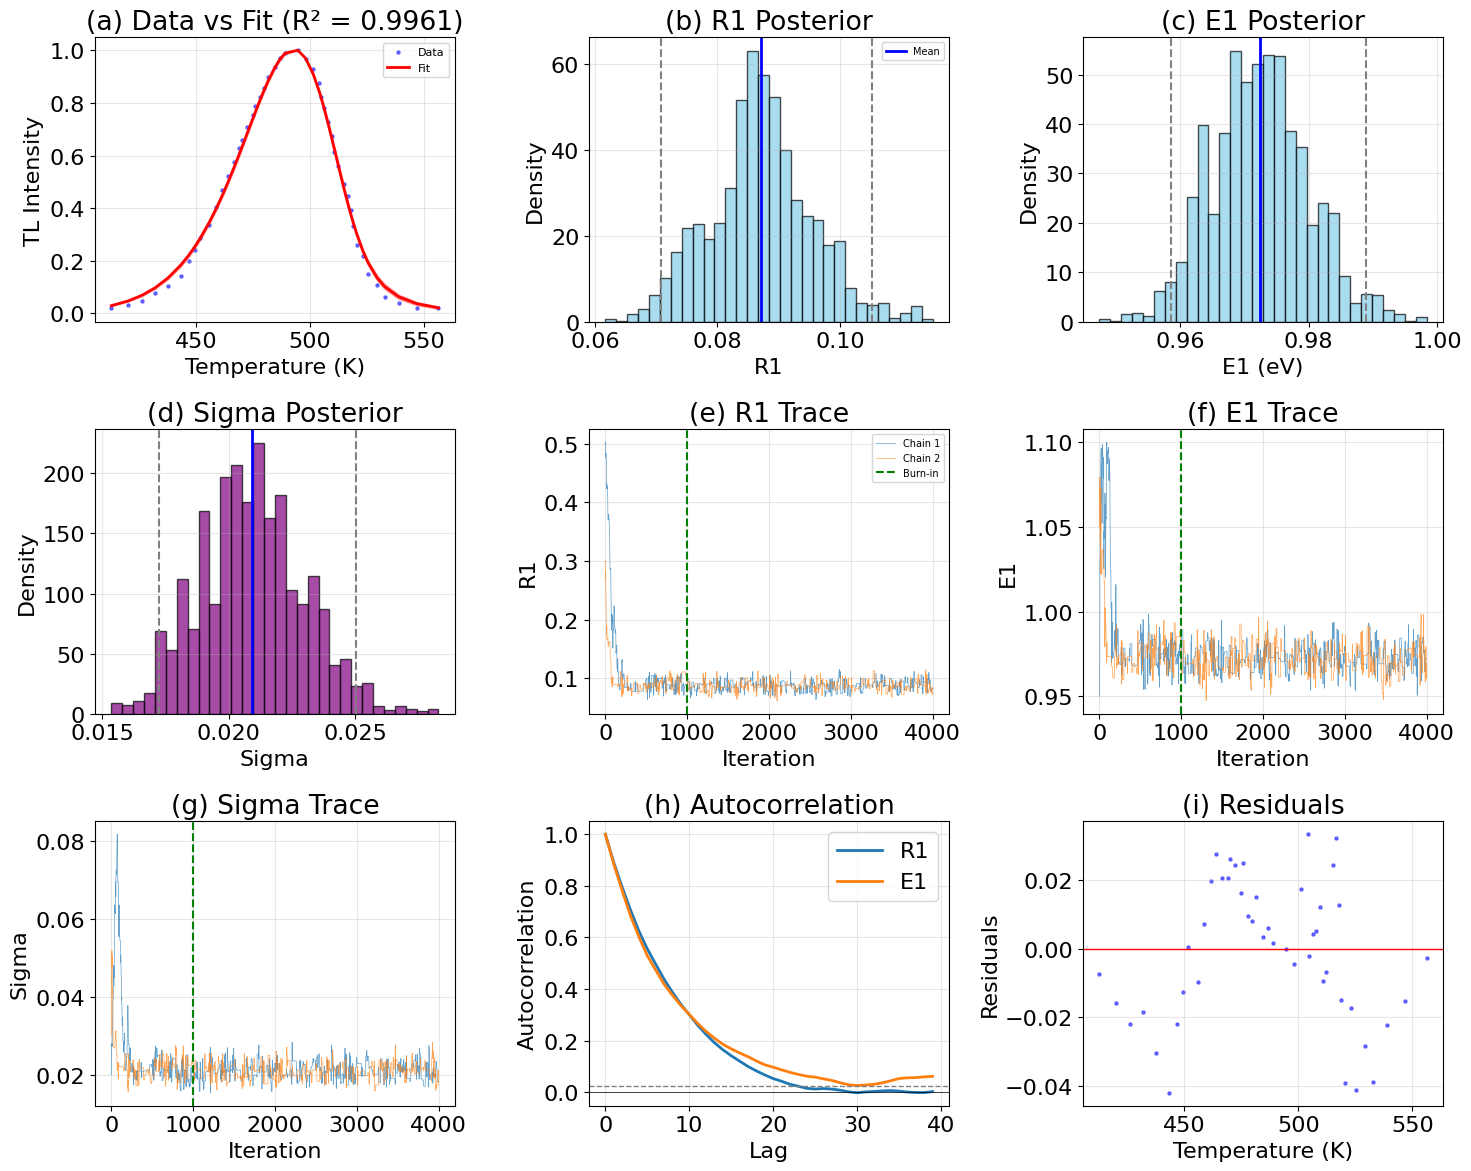


FINAL ESTIMATES
R1: 0.0871 ± 0.0085  [95% HPD: 0.0708, 0.1052]
E1: 0.9724 ± 0.0076  [95% HPD: 0.9585, 0.9889]
sigma: 0.0209 ± 0.0021  [95% HPD: 0.0172, 0.0251]

Acceptance rate: 0.126

✓ Results saved to 'metropolis_results.csv'


In [ ]:
%reset -f

import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import pandas as pd
import time

# =============================================================================
# DATA LOADING AND SETUP
# =============================================================================

np.random.seed(142)
plt.rcParams["font.size"] = 16

def readData():
    """Read TL data from GitHub."""
    url = 'https://github.com/vpagonis/Python-Codes/raw/main/Ch3PagonisGitHub/aluminaTLshort.TXT'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy() + 273.15  # temperature in Kelvin
    y_data = df.iloc[:, 1].to_numpy()

    # Normalize
    y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5

# Fixed parameters
FIXED_Imax = 1.0
FIXED_Tmax = Tmax_data

# Preliminary estimates
LS_estimates = {'R1': 0.15, 'E1': 1.0, 'sigma': 0.01}
LS_uncertainties = {'R1': 0.03, 'E1': 0.05, 'sigma': 0.001}

FIXED_Imax1 = 1.0
FIXED_Tmax1 = Tmax_data

print("="*60)
print("PYMC MODEL FOR SINGLE PEAK TL DATA - METROPOLIS SAMPLING")
print("="*60)
print("\nFixed parameters:")
print(f"  Imax1: {FIXED_Imax1:.2f}")
print(f"  Tmax1: {FIXED_Tmax1:.2f} K")

print("\nLeast squares estimates (used for prior means):")
print(f"  R1: {LS_estimates['R1']:.3f} ± {LS_uncertainties['R1']:.3f}")
print(f"  E1: {LS_estimates['E1']:.3f} ± {LS_uncertainties['E1']:.3f} eV")
print(f"  sigma: {LS_estimates['sigma']:.3f} ± {LS_uncertainties['sigma']:.3f}")

# =============================================================================
# VECTORIZED TL FUNCTION (NUMPY ONLY)
# =============================================================================

# Pre-compute constants for vectorized calculation
T = x_data
T2 = T**2
Tmax = FIXED_Tmax1
Tmax2 = Tmax**2
eps = 1e-10

# Pre-compute temperature-dependent values
kT_eps = kB * T + eps
kTmax_eps = kB * Tmax + eps

def tl_curve_numpy(R, E):
    """
    NumPy-based TL calculation.
    R and E are scalar values.
    """
    # Peak calculation
    exp_arg = -E / kT_eps
    exp_val = np.exp(exp_arg)

    F = kB * T2 * exp_val * (1 - 2*kB*T/(E + eps)) / (E + eps)

    exp_arg_m = -E / kTmax_eps
    exp_val_m = np.exp(exp_arg_m)
    Fm = kB * Tmax2 * exp_val_m * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)

    a = kB * Tmax2 * (1 - 1.05 * R**1.26) + eps
    term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
    exp_term = np.exp(E / kTmax_eps)

    Z = term1 + (F * E * exp_term) / a
    Zm = term1 + (Fm * E * exp_term) / a

    Z = np.clip(Z, -500, 500)
    Zm = np.clip(Zm, -500, 500)

    argW = np.log1p(np.exp(Z))
    argWm = np.log1p(np.exp(Zm))

    denominator = argW + argW**2 + eps

    result = FIXED_Imax1 * np.exp(-E/kT_eps * (Tmax - T)/Tmax) * (argWm + argWm**2) / denominator

    return np.where(np.isfinite(result), np.maximum(result, 0), 0)

def tl_curve_numpy_batch(params_batch):
    """
    Vectorized TL calculation for multiple parameter sets.
    params_batch: array of shape (n_samples, 3) with columns [R, E, sigma]
    Returns: array of shape (n_samples, n_temp)
    """
    if params_batch.ndim == 1:
        params_batch = params_batch.reshape(1, -1)

    n_samples = params_batch.shape[0]
    result = np.zeros((n_samples, len(T)))

    for i in range(n_samples):
        result[i] = tl_curve_numpy(params_batch[i, 0], params_batch[i, 1])

    return result

# =============================================================================
# SIMPLE METROPOLIS SAMPLER (NO PYMC FOR LIKELIHOOD)
# =============================================================================

# Beta parameters for R1
mu_R1 = LS_estimates['R1']
sigma_R1 = LS_uncertainties['R1']
var_R1 = sigma_R1**2
alpha_R1 = mu_R1 * (mu_R1 * (1 - mu_R1) / var_R1 - 1)
beta_R1 = (1 - mu_R1) * (mu_R1 * (1 - mu_R1) / var_R1 - 1)
alpha_R1 = max(alpha_R1, 1.01)
beta_R1 = max(beta_R1, 1.01)

# Prior functions
def log_prior(R, E, sigma):
    """Log prior probability."""
    if R <= 0 or R >= 1 or E < 0.8 or E > 1.1 or sigma <= 0:
        return -np.inf

    logp = (stats.beta.logpdf(R, alpha_R1, beta_R1) +
            stats.norm.logpdf(E, LS_estimates['E1'], LS_uncertainties['E1']*3) +
            stats.halfnorm.logpdf(sigma, scale=LS_estimates['sigma']*2))

    return logp

def log_likelihood(R, E, sigma):
    """Log likelihood."""
    mu = tl_curve_numpy(R, E)
    return np.sum(stats.norm.logpdf(y_data, mu, sigma))

def log_posterior(R, E, sigma):
    """Log posterior."""
    lp = log_prior(R, E, sigma)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(R, E, sigma)

def metropolis_sampler(n_iterations=3000, n_chains=2, tune=1000):
    """
    Simple Metropolis sampler.
    """
    param_names = ['R1', 'E1', 'sigma']
    n_params = 3

    # Proposal scales
    scales = np.array([0.02, 0.02, 0.005])

    # Initialize chains
    samples = np.zeros((n_chains, n_iterations + tune, n_params))
    acceptance = np.zeros((n_chains, n_iterations + tune))

    print("\nRunning Metropolis sampler...")

    for chain in range(n_chains):
        print(f"Evaluating chain {chain+1}")

        # Initialize
        if chain == 0:
            current = np.array([0.5, 0.95, 0.02])
        else:
            current = np.array([0.3, 1.05, 0.03])

        current_logp = log_posterior(current[0], current[1], current[2])

        for i in range(n_iterations + tune):
            # Store current
            samples[chain, i] = current

            # Propose new values (update all parameters at once for simplicity)
            proposal = current + np.random.normal(0, scales)

            # Check bounds
            if (proposal[0] <= 0 or proposal[0] >= 1 or
                proposal[1] < 0.8 or proposal[1] > 1.1 or
                proposal[2] <= 0):
                acceptance[chain, i] = 0
                continue

            # Compute log posterior for proposal
            proposal_logp = log_posterior(proposal[0], proposal[1], proposal[2])

            # Metropolis acceptance
            if np.log(np.random.random()) < proposal_logp - current_logp:
                current = proposal
                current_logp = proposal_logp
                acceptance[chain, i] = 1
            else:
                acceptance[chain, i] = 0

        print(f"  Chain {chain+1} acceptance rate: {np.mean(acceptance[chain]):.3f}")

    return samples, acceptance, param_names

# Run sampler
samples, acceptance, param_names = metropolis_sampler(n_iterations=3000, n_chains=2, tune=1000)

# Process samples
n_tune = 1000
samples_after_burnin = samples[:, n_tune:, :]
samples_flat = samples_after_burnin.reshape(-1, 3)

# Calculate statistics
means = np.mean(samples_flat, axis=0)
stds = np.std(samples_flat, axis=0)
hpd_lower = np.percentile(samples_flat, 2.5, axis=0)
hpd_upper = np.percentile(samples_flat, 97.5, axis=0)

# Print summary
print("\n" + "="*80)
print("PARAMETER SUMMARY")
print("="*80)
print(f"{'Parameter':<8} {'Mean':<10} {'Std':<10} {'95% HPD Lower':<15} {'95% HPD Upper':<15}")
print("-"*60)
for i, name in enumerate(param_names):
    print(f"{name:<8} {means[i]:<10.4f} {stds[i]:<10.4f} {hpd_lower[i]:<15.4f} {hpd_upper[i]:<15.4f}")

# =============================================================================
# CALCULATE FIT
# =============================================================================

print("\nCalculating fit statistics...")
n_fit = min(500, len(samples_flat))
indices = np.random.choice(len(samples_flat), n_fit, replace=False)
mu_samples = tl_curve_numpy_batch(samples_flat[indices])

mu_mean = np.mean(mu_samples, axis=0)
mu_hpd_lower = np.percentile(mu_samples, 2.5, axis=0)
mu_hpd_upper = np.percentile(mu_samples, 97.5, axis=0)

# Calculate R-squared
residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"\nR-squared: {r_squared:.4f}")

# =============================================================================
# PLOTTING
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Plot 1: Data vs Fit
ax = axes[0, 0]
ax.scatter(x_data, y_data, s=5, alpha=0.5, color='blue', label='Data')
ax.plot(x_data, mu_mean, 'r-', linewidth=2, label='Fit')
ax.fill_between(x_data, mu_hpd_lower, mu_hpd_upper, alpha=0.3, color='red')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('TL Intensity')
ax.set_title(f'(a) Data vs Fit (R² = {r_squared:.4f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: R1 Posterior
ax = axes[0, 1]
ax.hist(samples_flat[:, 0], bins=30, density=True, alpha=0.7,
        color='skyblue', edgecolor='black')
ax.axvline(means[0], color='blue', linewidth=2, label='Mean')
ax.axvline(hpd_lower[0], color='gray', linestyle='--')
ax.axvline(hpd_upper[0], color='gray', linestyle='--')
ax.set_xlabel('R1')
ax.set_ylabel('Density')
ax.set_title('(b) R1 Posterior')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 3: E1 Posterior
ax = axes[0, 2]
ax.hist(samples_flat[:, 1], bins=30, density=True, alpha=0.7,
        color='skyblue', edgecolor='black')
ax.axvline(means[1], color='blue', linewidth=2)
ax.axvline(hpd_lower[1], color='gray', linestyle='--')
ax.axvline(hpd_upper[1], color='gray', linestyle='--')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Density')
ax.set_title('(c) E1 Posterior')
ax.grid(True, alpha=0.3)

# Plot 4: Sigma Posterior
ax = axes[1, 0]
ax.hist(samples_flat[:, 2], bins=30, density=True, alpha=0.7,
        color='purple', edgecolor='black')
ax.axvline(means[2], color='blue', linewidth=2)
ax.axvline(hpd_lower[2], color='gray', linestyle='--')
ax.axvline(hpd_upper[2], color='gray', linestyle='--')
ax.set_xlabel('Sigma')
ax.set_ylabel('Density')
ax.set_title('(d) Sigma Posterior')
ax.grid(True, alpha=0.3)

# Plot 5: R1 Trace
ax = axes[1, 1]
for chain in range(2):
    ax.plot(samples[chain, :, 0], alpha=0.7, linewidth=0.5, label=f'Chain {chain+1}')
ax.axvline(1000, color='green', linestyle='--', label='Burn-in')
ax.set_xlabel('Iteration')
ax.set_ylabel('R1')
ax.set_title('(e) R1 Trace')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 6: E1 Trace
ax = axes[1, 2]
for chain in range(2):
    ax.plot(samples[chain, :, 1], alpha=0.7, linewidth=0.5)
ax.axvline(1000, color='green', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('E1')
ax.set_title('(f) E1 Trace')
ax.grid(True, alpha=0.3)

# Plot 7: Sigma Trace
ax = axes[2, 0]
for chain in range(2):
    ax.plot(samples[chain, :, 2], alpha=0.7, linewidth=0.5)
ax.axvline(1000, color='green', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('Sigma')
ax.set_title('(g) Sigma Trace')
ax.grid(True, alpha=0.3)

# Plot 8: Autocorrelation
ax = axes[2, 1]
lags = 40
for i, name in enumerate(['R1', 'E1']):
    samples_param = samples_flat[:, i]
    n = len(samples_param)
    samples_centered = samples_param - np.mean(samples_param)
    acf = np.correlate(samples_centered, samples_centered, mode='full') / np.var(samples_param)
    acf = acf[n-1:n-1+lags] / (n - np.arange(lags))
    ax.plot(range(lags), acf, label=name, linewidth=2)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=1.96/np.sqrt(len(samples_flat)), color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title('(h) Autocorrelation')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 9: Residuals
ax = axes[2, 2]
ax.scatter(x_data, residuals, s=5, alpha=0.5, color='blue')
ax.axhline(0, color='red', linewidth=1)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Residuals')
ax.set_title('(i) Residuals')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print("FINAL ESTIMATES")
print("="*60)
for i, name in enumerate(param_names):
    print(f"{name}: {means[i]:.4f} ± {stds[i]:.4f}  [95% HPD: {hpd_lower[i]:.4f}, {hpd_upper[i]:.4f}]")

print(f"\nAcceptance rate: {np.mean(acceptance):.3f}")

# Save results
results_df = pd.DataFrame({
    'Parameter': param_names,
    'Mean': means,
    'Std': stds,
    'HDI_2.5%': hpd_lower,
    'HDI_97.5%': hpd_upper
})
results_df.to_csv('metropolis_results.csv', index=False)
print("\n✓ Results saved to 'metropolis_results.csv'")
# @

**Code 7** PyMC, slice, double peak

PYMC MODEL FOR TWO-PEAK TL DATA - SLICE SAMPLING

Fixed parameters:
  Imax1: 119.42
  Tmax1: 462.75 K
  Imax2: 19.85
  Tmax2: 523.38 K

Least squares estimates (used for prior means):
  R1: 0.150 ± 0.030
  E1: 1.220 ± 0.050 eV
  R2: 0.550 ± 0.040
  E2: 1.610 ± 0.060 eV
  sigma: 4.800 ± 0.500

R1 Beta prior: alpha=21.10, beta=119.57
R2 Beta prior: alpha=84.53, beta=69.16

Running MCMC sampling with SLICE sampler...

PARAMETER SUMMARY WITH INFORMATIVE PRIORS - SLICE SAMPLING
              mean        sd    hdi_2.5%   hdi_97.5%     r_hat
E1        1.267681  0.069361    1.140353    1.406837  1.004632
E2        1.550930  0.163047    1.251009    1.868936  1.001133
R1        0.169243  0.056656    0.071008    0.286440  1.002840
R2        0.535086  0.040280    0.455892    0.611636  1.002014
mu[0]     0.308907  0.103146    0.118463    0.507111  1.004654
mu[1]     0.508782  0.156623    0.214010    0.808954  1.004662
mu[2]     0.827565  0.233689    0.374267    1.267069  1.004662
mu[3]     1.329725

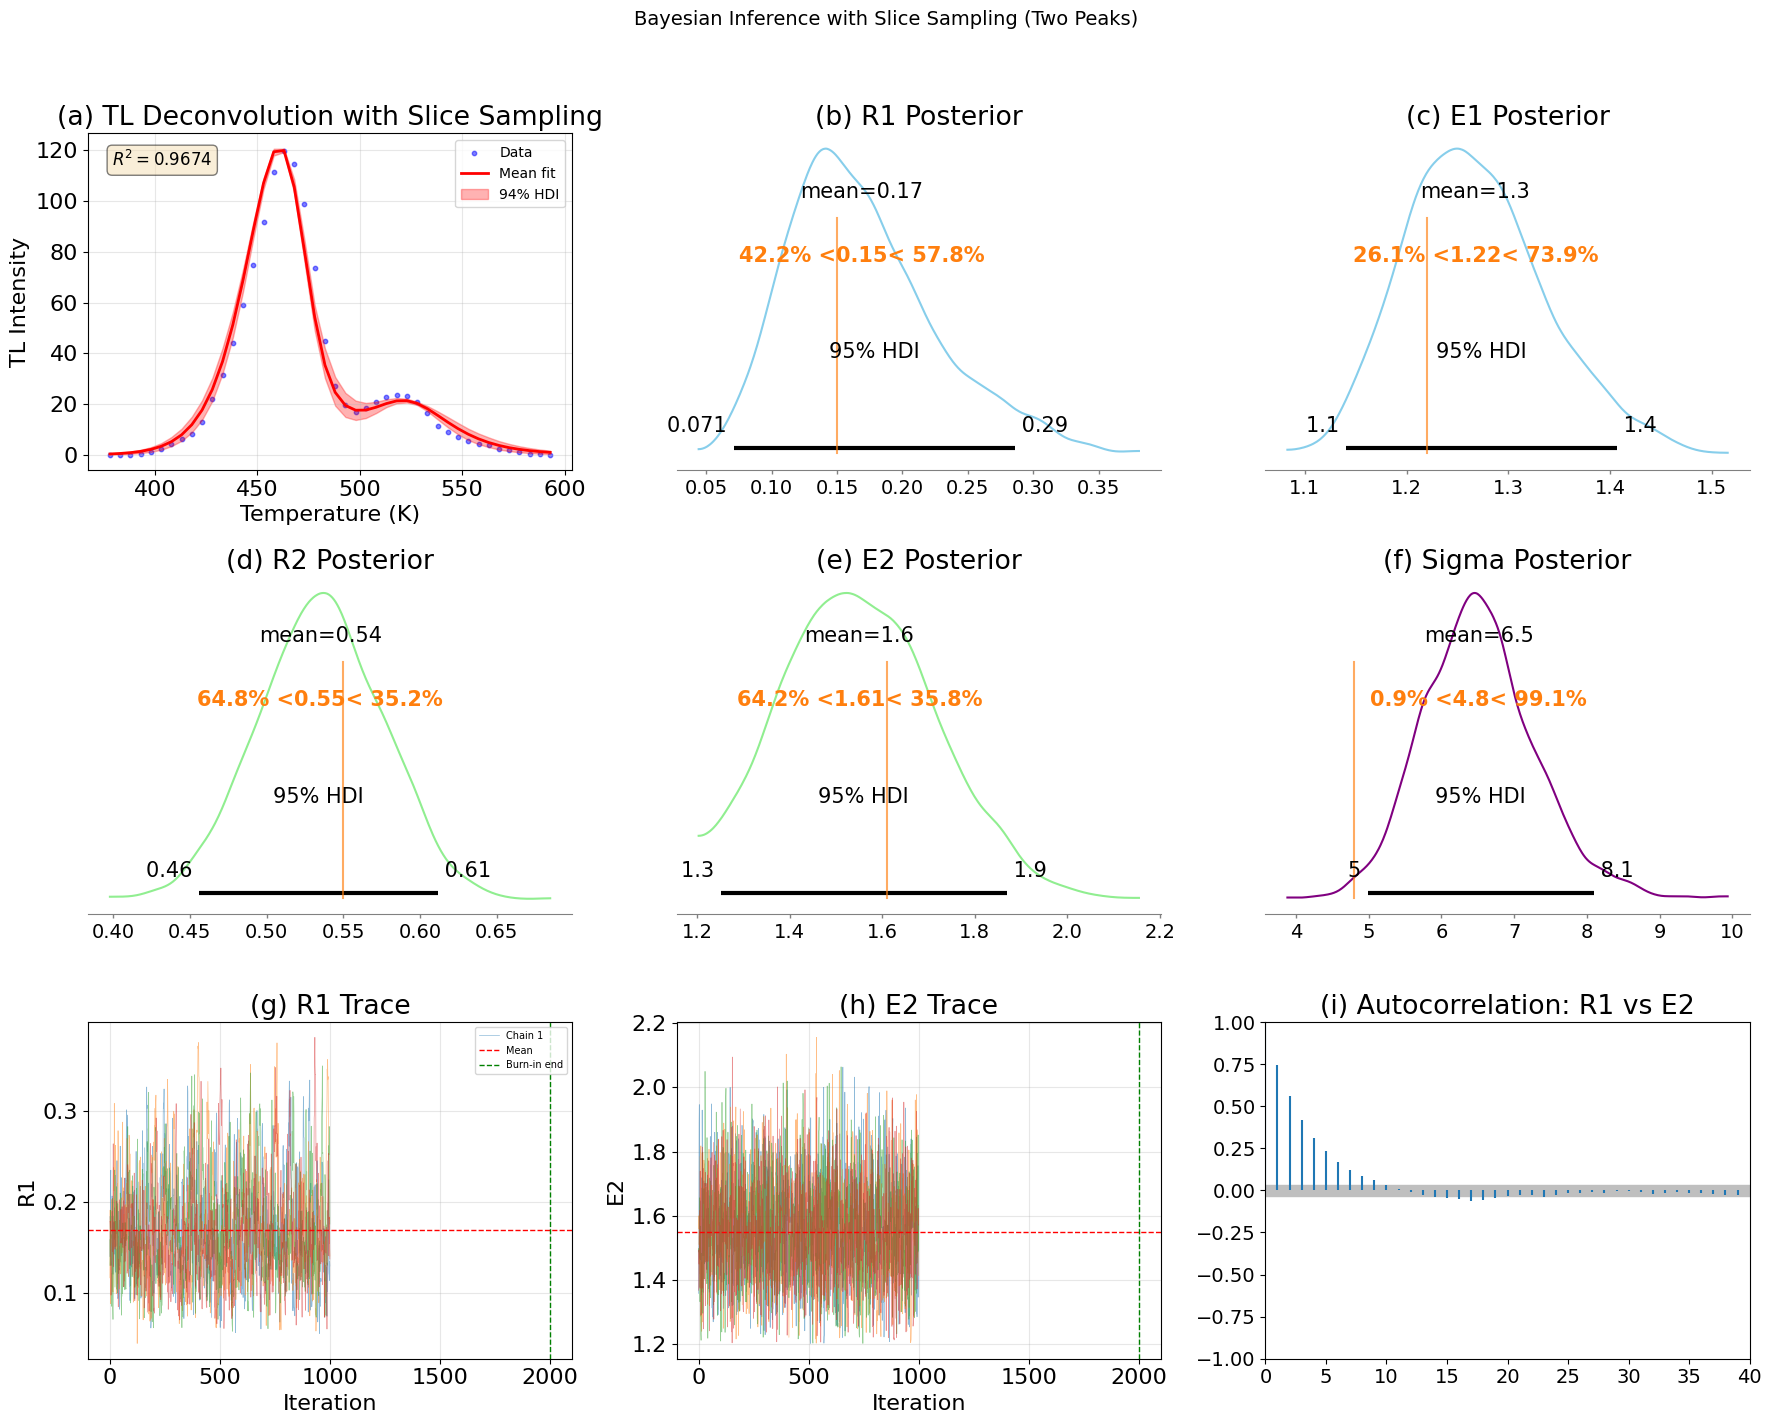

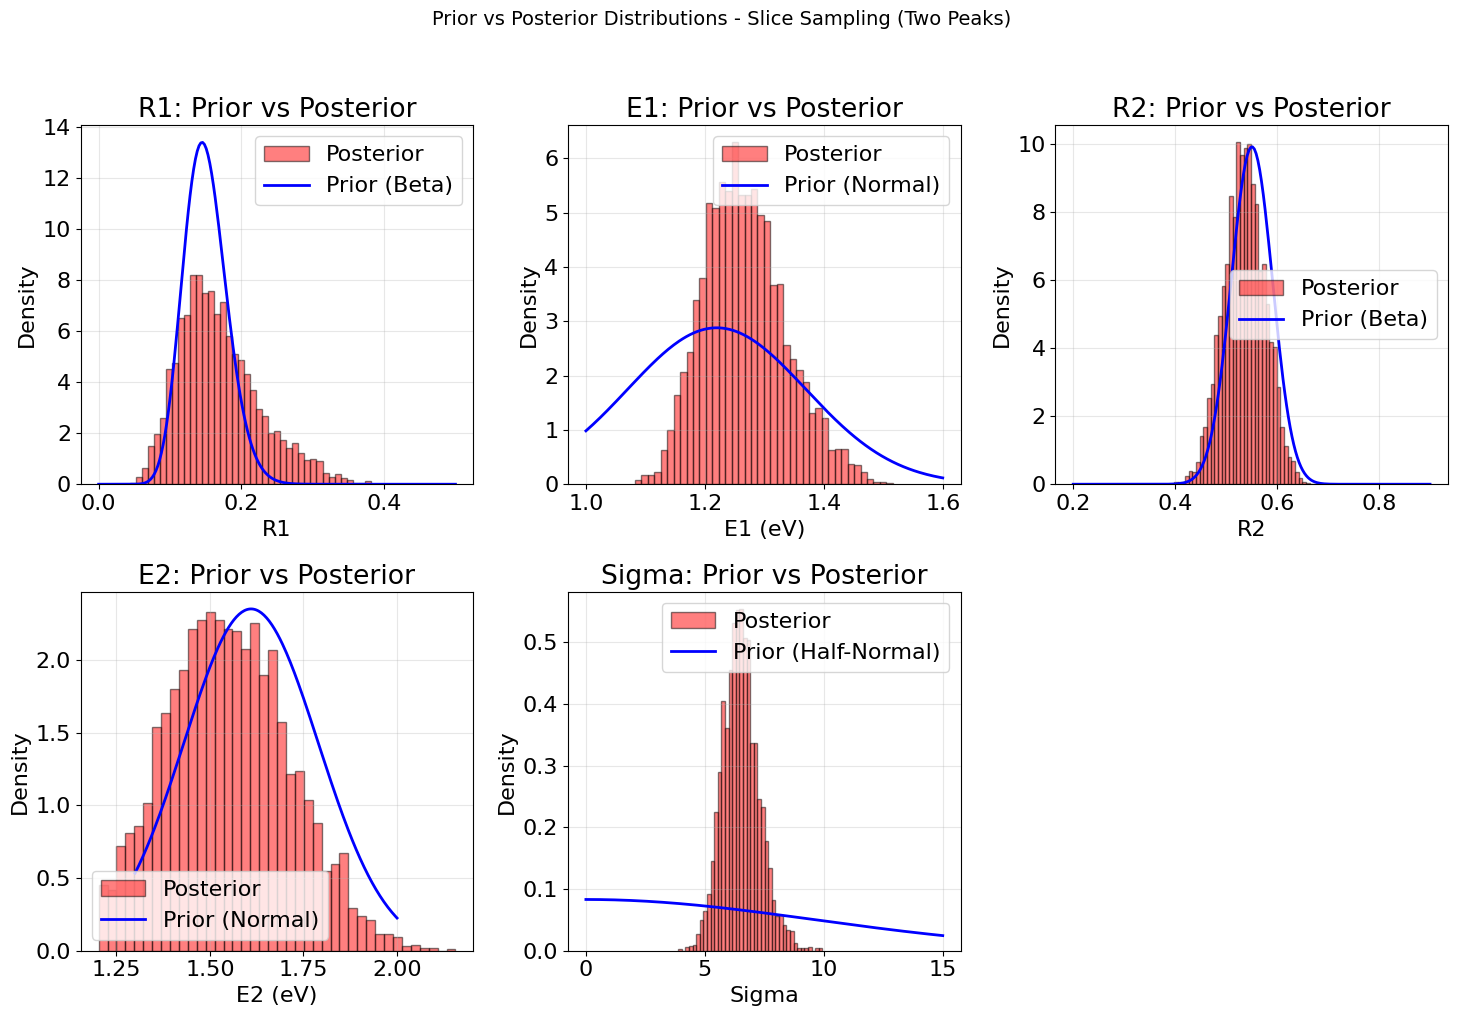


FIT STATISTICS
RMSE: 6.184536
R²: 0.967394
Adjusted R²: 0.964050
FOM: 14.3590%

FINAL PARAMETER ESTIMATES (Slice Sampling - Two Peaks)
R1: 0.1692 ± 0.0566  [95% HDI: 0.0710, 0.2864]
E1: 1.2677 ± 0.0694  [95% HDI: 1.1404, 1.4068]
R2: 0.5351 ± 0.0403  [95% HDI: 0.4559, 0.6116]
E2: 1.5509 ± 0.1630  [95% HDI: 1.2510, 1.8689]
sigma: 6.5128 ± 0.7826  [95% HDI: 4.9890, 8.0902]

SLICE SAMPLING EFFICIENCY
R1: 172.6 effective samples per 1000 draws
E1: 175.5 effective samples per 1000 draws
R2: 1004.7 effective samples per 1000 draws
E2: 590.7 effective samples per 1000 draws
sigma: 461.8 effective samples per 1000 draws

✓ Summary saved to 'parameter_summary_slice_two_peak.csv'

PYMC SLICE SAMPLER SUMMARY - TWO PEAKS
✓ Sampler: Slice sampler
✓ Total samples per chain: 5000 (after 2000 tune)
✓ Chains: 4
✓ Total posterior samples: 4000


In [ ]:
%reset -f

import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
from scipy import stats

def readData():
    """Read TL data from GitHub."""
    url = 'https://raw.githubusercontent.com/vpagonis/Python-Codes/refs/heads/main/Ch3PagonisGitHub/lbodata.txt'
    df = pd.read_table(url)

    x_data = df.iloc[:, 0].to_numpy()   # temperature in Kelvin
    y_data = df.iloc[:, 1].to_numpy()

    # Normalize
    # y_data = y_data / np.max(y_data)
    Tmax = x_data[np.argmax(y_data)]

    return x_data, y_data, Tmax

# Load data
x_data, y_data, Tmax_data = readData()
kB = 8.617E-5


# FIXED PARAMETERS (from previous fit or known values)
FIXED_Imax1 = 119.42
FIXED_Tmax1 = 462.75
FIXED_Imax2 = 19.85
FIXED_Tmax2 = 523.38

# PRELIMINARY LEAST SQUARES ESTIMATES
LS_estimates = {
    'R1': 0.15,
    'E1': 1.22,
    'R2': 0.55,
    'E2': 1.61,
    'sigma': 4.8
}

# Uncertainty estimates from least squares
LS_uncertainties = {
    'R1': 0.03,
    'E1': 0.05,
    'R2': 0.04,
    'E2': 0.06,
    'sigma': 0.5
}

print("="*60)
print("PYMC MODEL FOR TWO-PEAK TL DATA - SLICE SAMPLING")
print("="*60)
print("\nFixed parameters:")
print(f"  Imax1: {FIXED_Imax1:.2f}")
print(f"  Tmax1: {FIXED_Tmax1:.2f} K")
print(f"  Imax2: {FIXED_Imax2:.2f}")
print(f"  Tmax2: {FIXED_Tmax2:.2f} K")

print("\nLeast squares estimates (used for prior means):")
print(f"  R1: {LS_estimates['R1']:.3f} ± {LS_uncertainties['R1']:.3f}")
print(f"  E1: {LS_estimates['E1']:.3f} ± {LS_uncertainties['E1']:.3f} eV")
print(f"  R2: {LS_estimates['R2']:.3f} ± {LS_uncertainties['R2']:.3f}")
print(f"  E2: {LS_estimates['E2']:.3f} ± {LS_uncertainties['E2']:.3f} eV")
print(f"  sigma: {LS_estimates['sigma']:.3f} ± {LS_uncertainties['sigma']:.3f}")

def tl_peak_intensity(T, Imax, Tmax, R, E):
    """
    Calculate thermoluminescence intensity for a single peak.
    """
    eps = 1e-10

    F = kB * (T**2) * np.exp(-E/(kB*T + eps)) * (1 - 2*kB*T/(E + eps)) / (E + eps)
    Fm = kB * (Tmax**2) * np.exp(-E/(kB*Tmax + eps)) * (1 - 2*kB*Tmax/(E + eps)) / (E + eps)
    a = kB * Tmax**2 * (1 - 1.05 * R**1.26) + eps
    term1 = R/(1-R + eps) - np.log((1-R)/(R + eps) + eps)
    exp_term = np.exp(E/(kB*Tmax + eps))

    Z = term1 + (F * E * exp_term) / a
    Zm = term1 + (Fm * E * exp_term) / a

    argW = np.log(1 + np.exp(Z))
    argWm = np.log(1 + np.exp(Zm))

    return Imax * np.exp(-E/(kB*T + eps) * (Tmax - T)/Tmax) * (argWm + argWm**2) / (argW + argW**2 + eps)

def tl_glow_curve_two_peak(T, R1, E1, R2, E2):
    """
    Calculate total thermoluminescence intensity for two peaks.
    """
    peak1 = tl_peak_intensity(T, FIXED_Imax1, FIXED_Tmax1, R1, E1)
    peak2 = tl_peak_intensity(T, FIXED_Imax2, FIXED_Tmax2, R2, E2)
    return peak1 + peak2

# =============================================================================
# PYMC MODEL WITH INFORMATIVE PRIORS - TWO PEAKS
# =============================================================================

with pm.Model() as tl_model_two_peak:

    # =========================================================================
    # INFORMATIVE PRIORS BASED ON LEAST SQUARES
    # =========================================================================

    # R1: Beta distribution (bounded between 0 and 1)
    mu_R1 = LS_estimates['R1']
    sigma_R1 = LS_uncertainties['R1']
    var_R1 = sigma_R1**2

    # Calculate Beta parameters using method of moments
    alpha_R1 = mu_R1 * (mu_R1 * (1 - mu_R1) / var_R1 - 1)
    beta_R1 = (1 - mu_R1) * (mu_R1 * (1 - mu_R1) / var_R1 - 1)

    # Ensure positive parameters and avoid extreme values
    alpha_R1 = max(alpha_R1, 1.5)
    beta_R1 = max(beta_R1, 1.5)

    print(f"\nR1 Beta prior: alpha={alpha_R1:.2f}, beta={beta_R1:.2f}")
    R1 = pm.Beta('R1', alpha=alpha_R1, beta=beta_R1)

    # E1: Truncated Normal to keep within physical bounds
    E1 = pm.TruncatedNormal('E1', mu=LS_estimates['E1'], sigma=LS_uncertainties['E1']*3,
                            lower=1.0, upper=1.8)

    # R2: Beta distribution
    mu_R2 = LS_estimates['R2']
    sigma_R2 = LS_uncertainties['R2']
    var_R2 = sigma_R2**2

    alpha_R2 = mu_R2 * (mu_R2 * (1 - mu_R2) / var_R2 - 1)
    beta_R2 = (1 - mu_R2) * (mu_R2 * (1 - mu_R2) / var_R2 - 1)

    alpha_R2 = max(alpha_R2, 1.5)
    beta_R2 = max(beta_R2, 1.5)

    print(f"R2 Beta prior: alpha={alpha_R2:.2f}, beta={beta_R2:.2f}")
    R2 = pm.Beta('R2', alpha=alpha_R2, beta=beta_R2)

    # E2: Truncated Normal
    E2 = pm.TruncatedNormal('E2', mu=LS_estimates['E2'], sigma=LS_uncertainties['E2']*3,
                            lower=1.2, upper=2.2)

    # sigma: Half-Normal (positive only)
    sigma = pm.HalfNormal('sigma', sigma=LS_estimates['sigma']*2)

    # =========================================================================
    # DETERMINISTIC CALCULATIONS
    # =========================================================================

    # Calculate mu using fixed Imax/Tmax and free R/E
    mu = pm.Deterministic('mu', tl_glow_curve_two_peak(x_data, R1, E1, R2, E2))

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_data)

    # =========================================================================
    # SLICE SAMPLING
    # =========================================================================

    print("\nRunning MCMC sampling with SLICE sampler...")

    # Create Slice step for each variable
    # Slice sampler requires less tuning than Metropolis
    step = pm.Slice(vars=[R1, E1, R2, E2, sigma])

    # Run sampling with Slice sampler
    trace = pm.sample(draws=1000,           # Number of samples after tune
                      tune=400,             # Number of tuning samples
                      chains=4,               # Number of chains
                      step=step,               # Slice sampler
                      return_inferencedata=True,
                      progressbar=False,
                      idata_kwargs={'log_likelihood': True})

# =============================================================================
# SUMMARY AND DIAGNOSTICS
# =============================================================================

print("\n" + "="*80)
print("PARAMETER SUMMARY WITH INFORMATIVE PRIORS - SLICE SAMPLING")
print("="*80)

summary = az.summary(trace, hdi_prob=0.95, round_to=6)
print(summary[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'r_hat']])

# Check convergence
print("\n" + "="*80)
print("CONVERGENCE DIAGNOSTICS")
print("="*80)
max_rhat = summary['r_hat'].max()
print(f"Maximum R-hat: {max_rhat:.6f}")
if max_rhat < 1.01:
    print("✓ EXCELLENT convergence: All R-hat < 1.01")
elif max_rhat < 1.05:
    print("✓ GOOD convergence: All R-hat < 1.05")
elif max_rhat < 1.1:
    print("⚠ ACCEPTABLE convergence: R-hat < 1.1")
else:
    print("✗ POOR convergence: R-hat > 1.1 - may need more samples")

# Effective sample size
print("\n" + "="*80)
print("EFFECTIVE SAMPLE SIZE")
print("="*80)
n_chains = trace.posterior.dims['chain']
n_draws = trace.posterior.dims['draw']
n_samples_total = int(n_chains * n_draws)

for param in ['R1', 'E1', 'R2', 'E2', 'sigma']:
    ess_value = summary.loc[param, 'ess_bulk']
    if hasattr(ess_value, 'item'):
        ess_value = ess_value.item()
    else:
        ess_value = float(ess_value)

    percentage = (ess_value / n_samples_total) * 100
    print(f"{param}: ESS = {ess_value:.0f} ({percentage:.1f}% of {n_samples_total})")

# =============================================================================
# VISUALIZATION
# =============================================================================

# Create figure with subplots
fig = plt.figure(figsize=(18, 14))

# 1. Data vs Fit
ax1 = plt.subplot(3, 3, 1)
mu_mean = trace.posterior['mu'].mean(dim=['chain', 'draw']).values
mu_hdi = az.hdi(trace, var_names=['mu'], hdi_prob=0.94)

ax1.scatter(x_data, y_data, s=10, alpha=0.5, color='blue', label='Data')
ax1.plot(x_data, mu_mean, 'r-', linewidth=2, label='Mean fit')
ax1.fill_between(x_data, mu_hdi['mu'].sel(hdi='lower'), mu_hdi['mu'].sel(hdi='higher'),
                 alpha=0.3, color='red', label='94% HDI')
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('TL Intensity')
ax1.set_title('(a) TL Deconvolution with Slice Sampling')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Add text box with R² value
residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
textstr = f'$R^2 = {r_squared:.4f}$'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# 2. R1 Posterior
ax2 = plt.subplot(3, 3, 2)
az.plot_posterior(trace, var_names=['R1'], ax=ax2, hdi_prob=0.95,
                  ref_val=LS_estimates['R1'], color='skyblue')
ax2.set_title('(b) R1 Posterior')

# 3. E1 Posterior
ax3 = plt.subplot(3, 3, 3)
az.plot_posterior(trace, var_names=['E1'], ax=ax3, hdi_prob=0.95,
                  ref_val=LS_estimates['E1'], color='skyblue')
ax3.set_title('(c) E1 Posterior')

# 4. R2 Posterior
ax4 = plt.subplot(3, 3, 4)
az.plot_posterior(trace, var_names=['R2'], ax=ax4, hdi_prob=0.95,
                  ref_val=LS_estimates['R2'], color='lightgreen')
ax4.set_title('(d) R2 Posterior')

# 5. E2 Posterior
ax5 = plt.subplot(3, 3, 5)
az.plot_posterior(trace, var_names=['E2'], ax=ax5, hdi_prob=0.95,
                  ref_val=LS_estimates['E2'], color='lightgreen')
ax5.set_title('(e) E2 Posterior')

# 6. Sigma Posterior
ax6 = plt.subplot(3, 3, 6)
az.plot_posterior(trace, var_names=['sigma'], ax=ax6, hdi_prob=0.95,
                  ref_val=LS_estimates['sigma'], color='purple')
ax6.set_title('(f) Sigma Posterior')

# 7. Trace plot for R1
ax7 = plt.subplot(3, 3, 7)
param_to_plot = 'R1'
chain_data = trace.posterior[param_to_plot].values
for i in range(chain_data.shape[0]):
    ax7.plot(chain_data[i, :], alpha=0.5, linewidth=0.5, label=f'Chain {i+1}' if i==0 else '')
ax7.axhline(y=trace.posterior[param_to_plot].mean().values, color='red',
            linestyle='--', linewidth=1, label='Mean')
ax7.axvline(x=2000, color='green', linestyle='--', linewidth=1, label='Burn-in end')
ax7.set_xlabel('Iteration')
ax7.set_ylabel(param_to_plot)
ax7.set_title(f'(g) {param_to_plot} Trace')
ax7.legend(loc='upper right', fontsize=7)
ax7.grid(True, alpha=0.3)

# 8. E2 Trace
ax8 = plt.subplot(3, 3, 8)
param_to_plot = 'E2'
chain_data = trace.posterior[param_to_plot].values
for i in range(chain_data.shape[0]):
    ax8.plot(chain_data[i, :], alpha=0.5, linewidth=0.5)
ax8.axhline(y=trace.posterior[param_to_plot].mean().values, color='red',
            linestyle='--', linewidth=1)
ax8.axvline(x=2000, color='green', linestyle='--', linewidth=1)
ax8.set_xlabel('Iteration')
ax8.set_ylabel(param_to_plot)
ax8.set_title(f'(h) {param_to_plot} Trace')
ax8.grid(True, alpha=0.3)

# 9. Autocorrelation comparison
ax9 = plt.subplot(3, 3, 9)
az.plot_autocorr(trace, var_names=['R1', 'E2'], combined=True, max_lag=40, ax=ax9)
ax9.set_title('(i) Autocorrelation: R1 vs E2')

plt.suptitle('Bayesian Inference with Slice Sampling (Two Peaks)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# PRIOR VS POSTERIOR COMPARISON
# =============================================================================

fig_prior, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Prior vs Posterior for R1
ax1 = axes[0]
x_r1 = np.linspace(0, 0.5, 200)
prior_r1 = stats.beta.pdf(x_r1, alpha_R1, beta_R1)
post_r1 = trace.posterior['R1'].values.flatten()
ax1.hist(post_r1, bins=40, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax1.plot(x_r1, prior_r1, 'b-', linewidth=2, label='Prior (Beta)')
ax1.set_xlabel('R1')
ax1.set_ylabel('Density')
ax1.set_title('R1: Prior vs Posterior')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Prior vs Posterior for E1
ax2 = axes[1]
x_e1 = np.linspace(1.0, 1.6, 200)
prior_e1 = stats.norm.pdf(x_e1, LS_estimates['E1'], LS_uncertainties['E1']*3)
prior_e1 = prior_e1 / np.trapz(prior_e1, x_e1)  # Normalize
post_e1 = trace.posterior['E1'].values.flatten()
ax2.hist(post_e1, bins=40, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax2.plot(x_e1, prior_e1, 'b-', linewidth=2, label='Prior (Normal)')
ax2.set_xlabel('E1 (eV)')
ax2.set_ylabel('Density')
ax2.set_title('E1: Prior vs Posterior')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Prior vs Posterior for R2
ax3 = axes[2]
x_r2 = np.linspace(0.2, 0.9, 200)
prior_r2 = stats.beta.pdf(x_r2, alpha_R2, beta_R2)
post_r2 = trace.posterior['R2'].values.flatten()
ax3.hist(post_r2, bins=40, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax3.plot(x_r2, prior_r2, 'b-', linewidth=2, label='Prior (Beta)')
ax3.set_xlabel('R2')
ax3.set_ylabel('Density')
ax3.set_title('R2: Prior vs Posterior')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Prior vs Posterior for E2
ax4 = axes[3]
x_e2 = np.linspace(1.3, 2.0, 200)
prior_e2 = stats.norm.pdf(x_e2, LS_estimates['E2'], LS_uncertainties['E2']*3)
prior_e2 = prior_e2 / np.trapz(prior_e2, x_e2)  # Normalize
post_e2 = trace.posterior['E2'].values.flatten()
ax4.hist(post_e2, bins=40, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax4.plot(x_e2, prior_e2, 'b-', linewidth=2, label='Prior (Normal)')
ax4.set_xlabel('E2 (eV)')
ax4.set_ylabel('Density')
ax4.set_title('E2: Prior vs Posterior')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Prior vs Posterior for sigma
ax5 = axes[4]
x_sigma = np.linspace(0, 15, 200)
prior_sigma = stats.halfnorm.pdf(x_sigma, scale=LS_estimates['sigma']*2)
post_sigma = trace.posterior['sigma'].values.flatten()
ax5.hist(post_sigma, bins=40, density=True, alpha=0.5, color='red',
         edgecolor='black', label='Posterior')
ax5.plot(x_sigma, prior_sigma, 'b-', linewidth=2, label='Prior (Half-Normal)')
ax5.set_xlabel('Sigma')
ax5.set_ylabel('Density')
ax5.set_title('Sigma: Prior vs Posterior')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Hide empty subplot
axes[5].set_visible(False)

plt.suptitle('Prior vs Posterior Distributions - Slice Sampling (Two Peaks)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# FIT STATISTICS
# =============================================================================

print("\n" + "="*80)
print("FIT STATISTICS")
print("="*80)

residuals = y_data - mu_mean
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)
n = len(y_data)
p = 4  # number of free parameters (R1, E1, R2, E2)
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
rmse = np.sqrt(np.mean(residuals**2))
fom = np.sum(np.abs(residuals)) / np.sum(mu_mean) * 100

print(f"RMSE: {rmse:.6f}")
print(f"R²: {r_squared:.6f}")
print(f"Adjusted R²: {adj_r_squared:.6f}")
print(f"FOM: {fom:.4f}%")

# =============================================================================
# FINAL PARAMETER TABLE
# =============================================================================

print("\n" + "="*80)
print("FINAL PARAMETER ESTIMATES (Slice Sampling - Two Peaks)")
print("="*80)

for param in ['R1', 'E1', 'R2', 'E2', 'sigma']:
    mean = float(trace.posterior[param].mean().values)
    std = float(trace.posterior[param].std().values)
    hdi = az.hdi(trace, var_names=[param], hdi_prob=0.95)[param].values

    print(f"{param}: {mean:.4f} ± {std:.4f}  [95% HDI: {hdi[0]:.4f}, {hdi[1]:.4f}]")

# =============================================================================
# SLICE SAMPLING EFFICIENCY
# =============================================================================

print("\n" + "="*80)
print("SLICE SAMPLING EFFICIENCY")
print("="*80)

for param in ['R1', 'E1', 'R2', 'E2', 'sigma']:
    ess_value = summary.loc[param, 'ess_bulk']
    if hasattr(ess_value, 'item'):
        ess_value = ess_value.item()
    else:
        ess_value = float(ess_value)

    ess_per_1000 = ess_value / (n_samples_total / 1000)
    print(f"{param}: {ess_per_1000:.1f} effective samples per 1000 draws")

# =============================================================================
# SAVE RESULTS
# =============================================================================

summary.to_csv('parameter_summary_slice_two_peak.csv')
print("\n✓ Summary saved to 'parameter_summary_slice_two_peak.csv'")

print("\n" + "="*80)
print("PYMC SLICE SAMPLER SUMMARY - TWO PEAKS")
print("="*80)
print(f"✓ Sampler: Slice sampler")
print(f"✓ Total samples per chain: 5000 (after 2000 tune)")
print(f"✓ Chains: 4")
print(f"✓ Total posterior samples: {n_samples_total}")
print("="*80)

# Optional: Plot the slice sampling step sizes if available
if hasattr(trace, 'sample_stats') and 'step_size' in trace.sample_stats:
    fig_step, ax_step = plt.subplots(figsize=(10, 4))
    step_sizes = trace.sample_stats['step_size'].values
    if step_sizes.ndim == 3:
        step_sizes = step_sizes.squeeze()

    for chain in range(step_sizes.shape[0]):
        ax_step.plot(step_sizes[chain, :], alpha=0.7, linewidth=0.5,
                    label=f'Chain {chain+1}')
    ax_step.set_xlabel('Iteration')
    ax_step.set_ylabel('Step Size')
    ax_step.set_title('Slice Sampler Step Sizes by Chain')
    ax_step.legend(loc='upper right')
    ax_step.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
# @